# ConsDB + EFD to PSF Effects Diagnosis — LSSTCam Exploration

Joins **ConsDB** (`cdb_lsstcam`) science-exposure records to **EFD** telemetry,
building on `ESS_Wind_vs_DomePointing.ipynb`, to diagnose drivers of PSF behavior.

For each science exposure we combine:

| Source | Data |
|---|---|
| `cdb_lsstcam.exposure` | pointing, wind summary, filter, timing |
| `cdb_lsstcam.visit1_quicklook` | PSF σ, effective time, seeing, Zernikes, guider |
| `cdb_lsstcam.exposure_quicklook` | mount jitter, image degradation |
| EFD `lsst.sal.ESS.airFlow` index 301 | 20 Hz outside wind speed / direction |
| EFD `lsst.sal.MTDome.azimuth` | dome azimuth (not in ConsDB schema) |
| EFD `lsst.sal.MTDome.apertureShutter` | shutter state |
| EFD `lsst.sal.ESS.airTurbulence` indices 110, 123–126 | inside turbulence |

## Database
Host: `usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu`  
Database: `exposurelog`  
Credentials: `~/.lsst/postgres-credentials.txt` (pgpass format)  
No RSP bearer token required from SLAC compute nodes.

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [2]:
# ── ConsDB / PostgreSQL ───────────────────────────────────────────────────────
PGPASS_FILE  = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST  = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB    = "exposurelog"
CONSDB_USER  = "usdf"
SCHEMA       = "cdb_lsstcam"

def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) < 5:
                continue
            h, db, u_ = parts[0], parts[2], parts[3]
            pwd = ":".join(parts[4:])
            if h == host and db == database and u_ == user:
                return pwd
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

# Verify connection and available schemas
schemas = consdb_query(
    "SELECT schema_name FROM information_schema.schemata "
    "WHERE schema_name LIKE 'cdb_%' ORDER BY 1"
)
print("ConsDB schemas:")
display(schemas)

# ── Time window (matches ESS_Wind_vs_DomePointing.ipynb) ─────────────────────
t_end   = Time("2026-04-04T05:00:00", scale="utc")
t_start = t_end - TimeDelta(25 * u.week)
day_obs_start = int(t_start.strftime("%Y%m%d"))
day_obs_end   = int(t_end.strftime("%Y%m%d"))
print(f"\nTime window: {t_start.iso}  to  {t_end.iso}")
print(f"day_obs:     {day_obs_start}  to  {day_obs_end}")

# ── EFD ───────────────────────────────────────────────────────────────────────
EFD_ALIAS        = "usdf_efd"
flow_topic       = "lsst.sal.ESS.airFlow"
turb_topic       = "lsst.sal.ESS.airTurbulence"
dome_topic       = "lsst.sal.MTDome.azimuth"
shutter_topic    = "lsst.sal.MTDome.apertureShutter"
weather_index    = 301          # calibration hill weather station
shutter_threshold = 95.0        # % open to count as "open"

ess_sensors = {
    110: "TMA Platform",
    123: "Top Ring -X/-Y",
    124: "Top Ring +X/-Y",
    125: "Top Ring +X/+Y",
    126: "Top Ring -X/+Y",
}

# Wind speed bin thresholds (m/s) — matches parent notebook
wind_speed_bins   = [0, 3, 6, 9, 12, np.inf]
wind_speed_labels = ["0-3 m/s", "3-6 m/s", "6-9 m/s", "9-12 m/s", ">12 m/s"]
wind_speed_colors = ["steelblue", "mediumseagreen", "goldenrod", "tomato", "mediumpurple"]

# ── Mount jitter clip ─────────────────────────────────────────────────────────
MOUNT_JITTER_MIN = 0.0   # arcsec — exclude non-physical zero / negative values
MOUNT_JITTER_MAX = 1.0   # arcsec — exclude outliers / bad data above this threshold

# ── Parquet cache ────────────────────────────────────────────────────
CACHE_FILE           = "../data/consdb_efd_psf_joined.parquet"
FORCE_REFETCH        = False   # True → ignore cache, re-fetch everything
INCREMENTAL_REFETCH  = False   # True → extend cache with newer data


ConsDB schemas:


,schema_name
0,cdb_latiss
1,cdb_lsstcam
2,cdb_lsstcomcam
3,cdb_lsstcomcamsim
4,cdb_startrackerfast
5,cdb_startrackernarrow
6,cdb_startrackerwide



Time window: 2025-10-11 05:00:00.000  to  2026-04-04 05:00:00.000
day_obs:     20251011  to  20260404


In [ ]:
import pathlib as _pl
_cp = _pl.Path(CACHE_FILE)
_from_cache = False
if not FORCE_REFETCH and _cp.exists():
    df_work = pd.read_parquet(_cp)
    df_joined = df_work.copy()
    df_exp    = df_work   # for downstream quick-stats cells
    _from_cache = True
    print(f"✓ Loaded {len(df_work):,} rows from cache: {_cp}")
    print(f"  columns: {list(df_work.columns[:6])} ...")
elif FORCE_REFETCH:
    print("FORCE_REFETCH=True — bypassing cache")
else:
    print(f"No cache at {_cp} — will fetch fresh data")

## 1. ConsDB Schema Exploration

Inspect the LSSTCam schema before querying — column names differ from the older
LATISS schema and from the REST API documentation.

In [3]:
# Tables in cdb_lsstcam
tables = consdb_query(f"""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = '{SCHEMA}'
    ORDER BY table_name
""")
print(f"Tables in {SCHEMA}:")
display(tables)

Tables in cdb_lsstcam:


,table_name
0,ccdexposure
1,ccdexposure_camera
2,ccdexposure_flexdata
3,ccdexposure_flexdata_schema
4,ccdexposure_quicklook
5,ccdvisit1
6,ccdvisit1_quicklook
7,exposure
8,exposure_flexdata
9,exposure_flexdata_schema


In [4]:
from IPython.display import HTML, display

# Column listing for key tables
for tbl in ["exposure", "exposure_quicklook", "visit1_quicklook"]:
    cols = consdb_query(f"""
        SELECT column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = '{SCHEMA}' AND table_name = '{tbl}'
        ORDER BY ordinal_position
    """)
    print(f"\n[{SCHEMA}.{tbl}] - {len(cols)} columns:")

    if tbl == "visit1_quicklook":
        details_html = f"""
        <details open>
          <summary><b>Expand/Collapse {SCHEMA}.{tbl} columns</b></summary>
          {cols.to_html(index=False)}
        </details>
        """
        display(HTML(details_html))
    else:
        display(cols)


[cdb_lsstcam.exposure] - 51 columns:


,column_name,data_type
0,exposure_id,bigint
1,exposure_name,character varying
2,controller,character varying
3,day_obs,integer
4,seq_num,integer
5,physical_filter,character varying
6,band,character varying
7,s_ra,double precision
8,s_dec,double precision
9,sky_rotation,double precision



[cdb_lsstcam.exposure_quicklook] - 16 columns:


,column_name,data_type
0,exposure_id,bigint
1,day_obs,integer
2,seq_num,integer
3,postisr_pixel_median_median,double precision
4,postisr_pixel_median_mean,double precision
5,postisr_pixel_median_max,double precision
6,mount_motion_image_degradation,double precision
7,mount_motion_image_degradation_az,double precision
8,mount_motion_image_degradation_rot,double precision
9,mount_jitter_rms,double precision



[cdb_lsstcam.visit1_quicklook] - 166 columns:


column_name,data_type
visit_id,bigint
day_obs,integer
seq_num,integer
n_inputs,integer
pixel_scale_min,double precision
pixel_scale_max,double precision
pixel_scale_median,double precision
astrom_offset_mean_min,double precision
astrom_offset_mean_max,double precision
astrom_offset_mean_median,double precision


In [42]:
# Data summary: img_type distribution and date range
print("img_type counts:")
display(consdb_query(f"""
    SELECT img_type, count(*) AS n
    FROM {SCHEMA}.exposure
    GROUP BY img_type ORDER BY n DESC
"""))

print("\nScience exposures date range:")
display(consdb_query(f"""
    SELECT min(day_obs), max(day_obs), count(*) AS n
    FROM {SCHEMA}.exposure
    WHERE img_type = 'science'
"""))

print("\nquicklook coverage (exposures with visit1_quicklook):")
display(consdb_query(f"""
    SELECT count(DISTINCT e.exposure_id) AS n_with_quicklook
    FROM {SCHEMA}.exposure e
    JOIN {SCHEMA}.visit1_quicklook q ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
    WHERE e.img_type = 'science'
      AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
"""))

img_type counts:


,img_type,n
0,science,56767
1,acq,33190
2,flat,28406
3,bias,13020
4,dark,12408
5,cwfs,6091
6,engtest,2065
7,focus,176
8,indome,26
9,test,1



Science exposures date range:


,min,max,n
0,20250412,20260401,56767



quicklook coverage (exposures with visit1_quicklook):


,n_with_quicklook
0,32543


## 2. Fetch Science Exposures + Quicklook from ConsDB

### Column name changes vs LATISS / REST API docs

| `cdb_lsstcam` column | LATISS / old name | Notes |
|---|---|---|
| `img_type = 'science'` | `imgtype = 'OBJECT'` | lowercase in lsstcam |
| `obs_start` / `obs_start_mjd` | `obsstart` / `obsstartmjd` | now matches REST API |
| `exp_time` | `exptime` | |
| `s_ra` / `s_dec` | `ra` / `decl` | now matches REST API |
| `sky_rotation` | `skyrotation` | |
| `air_temp` | `airtemp` | |
| `exp_midpt` | `expmidpt` | |
| *(no dome_azimuth)* | `dome_azimuth` | fetch from EFD MTDome.azimuth |

`visit1_quicklook` adds PSF σ, effective time, seeing, Zernikes z4–z28, guider metrics.  
`exposure_quicklook` adds mount jitter and image degradation.

In [43]:
if not _from_cache:
    df_exp = consdb_query(f"""
        SELECT
            e.exposure_id,
            e.day_obs,
            e.seq_num,
            e.obs_start,
            e.obs_start_mjd,
            e.exp_time,
            e.airmass,
            e.s_ra,
            e.s_dec,
            e.azimuth,
            e.altitude,
            e.sky_rotation,
            e.wind_speed,
            e.wind_dir,
            e.dimm_seeing,
            e.air_temp,
            e.humidity,
            e.band,
            e.physical_filter,
            e.target_name,
            e.img_type,
            e.vignette,
            e.can_see_sky,
            e.scheduler_note,
            -- visit1_quicklook
            q.psf_sigma_median,
            q.seeing_zenith_500nm_median,
            q.eff_time_median,
            q.eff_time_zero_point_scale_median,
            q.sky_bg_median,
            q.zero_point_median,
            q.donut_blur_fwhm,
            q.aos_fwhm,
            q.z4, q.z5, q.z6, q.z7, q.z8, q.z9, q.z10, q.z11,
            -- mount (from exposure_quicklook)
            m.mount_motion_image_degradation,
            m.mount_motion_image_degradation_az,
            m.mount_motion_image_degradation_el,
            m.mount_motion_image_degradation_rot,
            m.mount_jitter_rms,
            m.mount_jitter_rms_az,
            m.mount_jitter_rms_el,
            m.mount_jitter_rms_rot
        FROM {SCHEMA}.exposure e
        LEFT JOIN {SCHEMA}.visit1_quicklook  q ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
        LEFT JOIN {SCHEMA}.exposure_quicklook m ON m.day_obs = e.day_obs AND m.seq_num = e.seq_num
        WHERE e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
          AND e.img_type = 'science'
        ORDER BY e.obs_start_mjd
    """)
    
    df_exp["obs_start_utc"] = pd.to_datetime(df_exp["obs_start"], utc=True)
    df_exp = df_exp.sort_values("obs_start_utc").set_index("obs_start_utc")
    
    print(f"Science exposures  : {len(df_exp)}")
    print(f"Date range         : {df_exp.index.min()} → {df_exp.index.max()}")
    print(f"With PSF sigma     : {df_exp['psf_sigma_median'].notna().sum()}")
    print(f"With donut blur    : {df_exp['donut_blur_fwhm'].notna().sum()}")
    print(f"With AOS FWHM      : {df_exp['aos_fwhm'].notna().sum()}")
    print(f"With ZP scale      : {df_exp['eff_time_zero_point_scale_median'].notna().sum()}")
    print(f"With mount jitter  : {df_exp['mount_jitter_rms'].notna().sum()}")
    print(f"With mount motion  : {df_exp['mount_motion_image_degradation'].notna().sum()}")
    df_exp.head()

Science exposures  : 33006
Date range         : 2025-10-25 01:29:23.620000+00:00 → 2026-04-02 02:01:36.519000+00:00
With PSF sigma     : 32269
With donut blur    : 32291
With AOS FWHM      : 32291
With ZP scale      : 32213
With mount jitter  : 14056
With mount motion  : 14056


,exposure_id,day_obs,seq_num,obs_start,obs_start_mjd,exp_time,airmass,s_ra,s_dec,azimuth,...,z10,z11,mount_motion_image_degradation,mount_motion_image_degradation_az,mount_motion_image_degradation_el,mount_motion_image_degradation_rot,mount_jitter_rms,mount_jitter_rms_az,mount_jitter_rms_el,mount_jitter_rms_rot
obs_start_utc,,,,,,,,,,,,,,,,,,,,,
2025-10-25 01:29:23.620000+00:00,2025102400105,20251024,105,2025-10-25 01:29:23.620,60973.062079,30.0,1.048508,331.902574,-17.358498,314.811336,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:30:06.907000+00:00,2025102400106,20251024,106,2025-10-25 01:30:06.907,60973.062580,30.0,1.061767,328.799598,-17.329091,307.671873,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:30:46.123000+00:00,2025102400107,20251024,107,2025-10-25 01:30:46.123,60973.063034,30.0,1.046469,329.972344,-19.996186,303.465543,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:31:34.642000+00:00,2025102400108,20251024,108,2025-10-25 01:31:34.642,60973.063595,30.0,1.046454,328.126653,-22.706518,292.260500,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-25 01:32:14.839000+00:00,2025102400109,20251024,109,2025-10-25 01:32:14.839,60973.064061,30.0,1.062649,325.056555,-22.668908,287.864861,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Quick statistics
print("Band distribution:")
display(df_exp["band"].value_counts())

print("\nPSF sigma median (pixels):")
display(df_exp["psf_sigma_median"].describe())

print("\nWind speed (m/s):")
display(df_exp["wind_speed"].describe())

print("\nMount jitter RMS (arcsec):")
display(df_exp["mount_jitter_rms"].describe())

Band distribution:


band
i    13308
z     6788
y     6287
r     3417
g     2635
u      571
Name: count, dtype: int64


PSF sigma median (pixels):


count    32269.000000
mean         2.213334
std          0.513008
min          1.205976
25%          1.879955
50%          2.097917
75%          2.398107
max          7.701598
Name: psf_sigma_median, dtype: float64


Wind speed (m/s):


count    33006.000000
mean         3.930415
std          2.965980
min          0.000000
25%          1.751400
50%          3.252600
75%          5.421000
max         17.097000
Name: wind_speed, dtype: float64


Mount jitter RMS (arcsec):


count    14056.000000
mean         0.268524
std         18.629867
min          0.002807
25%          0.004864
50%          0.005628
75%          0.006845
max       2162.096975
Name: mount_jitter_rms, dtype: float64

## 3. Fetch EFD Telemetry

Same topics as `ESS_Wind_vs_DomePointing.ipynb`:

| Topic | Index | Fields | Purpose |
|---|---|---|---|
| `lsst.sal.ESS.airFlow` | 301 | `speed`, `direction` | Outside wind |
| `lsst.sal.MTDome.azimuth` | — | `positionActual` | Dome azimuth (not in ConsDB) |
| `lsst.sal.MTDome.apertureShutter` | — | `positionActual0/1` | Shutter state |
| `lsst.sal.ESS.airTurbulence` | 110, 123–126 | `speedMagnitude`, `sonicTemperatureStdDev` | Inside turbulence |

In [45]:
efd_client = EfdClient(EFD_ALIAS)
print("Connected to EFD")

Connected to EFD


In [46]:
if not _from_cache:
    # Outside wind (ESS:301)
    df_wind_raw = await efd_client.select_time_series(
        flow_topic,
        fields=["direction", "speed"],
        start=t_start,
        end=t_end,
        index=weather_index,
    )
    print(f"ESS:{weather_index} airFlow rows: {len(df_wind_raw)}")
    df_wind_raw.head()

ESS:301 airFlow rows: 11632889


,direction,speed
2025-10-11 05:00:00.155724+00:00,11.870013,5.4210
2025-10-11 05:00:01.436087+00:00,11.604870,5.2542
2025-10-11 05:00:02.715952+00:00,14.015000,5.2542
2025-10-11 05:00:03.996410+00:00,11.659986,5.2542
2025-10-11 05:00:05.275245+00:00,11.624985,5.2542


In [47]:
if not _from_cache:
    # Dome azimuth — needed for relative wind pointing (not stored in cdb_lsstcam.exposure)
    df_dome = await efd_client.select_time_series(
        dome_topic,
        fields="positionActual",
        start=t_start,
        end=t_end,
    )
    print(f"Dome azimuth rows: {len(df_dome)}")
    df_dome.head()

Dome azimuth rows: 25331811


,positionActual
2025-10-13 19:18:07.314967+00:00,147.648163
2025-10-13 19:18:07.527566+00:00,147.648163
2025-10-13 19:18:08.542858+00:00,147.648163
2025-10-13 19:18:08.895768+00:00,147.648163
2025-10-13 19:18:09.252082+00:00,147.648163


In [48]:
if not _from_cache:
    # Aperture shutter (to flag shutter-open science exposures)
    df_shutter = await efd_client.select_time_series(
        shutter_topic,
        fields=["positionActual0", "positionActual1"],
        start=t_start,
        end=t_end,
    )
    print(f"Shutter rows: {len(df_shutter)}")
    df_shutter.head()

Shutter rows: 9994583


,positionActual0,positionActual1
2025-10-13 19:18:07.727178+00:00,0.0,0.03
2025-10-13 19:18:09.351868+00:00,0.0,0.03
2025-10-13 19:18:10.471878+00:00,0.0,0.03
2025-10-13 19:18:11.896074+00:00,0.0,0.03
2025-10-13 19:18:13.114407+00:00,0.0,0.03


In [49]:
if not _from_cache:
    # Inside turbulence sensors
    ess_data = {}
    for idx, label in ess_sensors.items():
        df = await efd_client.select_time_series(
            turb_topic,
            fields=["speedMagnitude", "sonicTemperatureStdDev"],
            start=t_start,
            end=t_end,
            index=idx,
        )
        ess_data[idx] = df
        print(f"  [{idx}] {label:20s}  rows={len(df)}")

  [110] TMA Platform          rows=2962390
  [123] Top Ring -X/-Y        rows=1060774
  [124] Top Ring +X/-Y        rows=1061532
  [125] Top Ring +X/+Y        rows=1059606
  [126] Top Ring -X/+Y        rows=1062141


In [40]:
if not _from_cache:
    # M1M3 IMS (mirror rigid-body position)
    # Fields: x/y/z translation (microns) and x/y/z rotation (arcsec)
    # NOTE: update topic names / fields based on the diagnostic cell output above
    mirror_topics = {
        "m1m3_ims": {
            "topic":  "lsst.sal.MTM1M3.imsData",
            "fields": ["xPosition", "yPosition", "zPosition",
                       "xRotation", "yRotation", "zRotation"],
        },
        "m1m3_hp": {
            "topic":  "lsst.sal.MTM1M3.hardpointActuatorData",
            "fields": [f"measuredForce{i}" for i in range(6)],
        },
        "m2_pos": {
            "topic":  "lsst.sal.MTM2.positionIMS",
            "fields": ["x", "y", "z", "xRot", "yRot", "zRot"],
        },
    }
    
    
    async def fetch_chunked(client, topic, fields, t0, t1, chunk=TimeDelta(1 * u.day)):
        """
        Fetch a time-series topic in daily (or `chunk`-sized) pieces to stay
        under the EFD row limit, then concatenate into a single DataFrame.
        """
        chunks = []
        t_lo   = t0
        while t_lo < t1:
            t_hi = min(t_lo + chunk, t1)
            try:
                df = await client.select_time_series(
                    topic, fields=fields, start=t_lo, end=t_hi,
                )
                if not df.empty:
                    chunks.append(df)
            except Exception as e:
                print(f"    chunk {t_lo.iso[:10]} error: {e}")
            t_lo = t_hi
    
        if not chunks:
            return pd.DataFrame()
        return pd.concat(chunks).sort_index()
    
    
    mirror_data = {}
    for key, cfg in mirror_topics.items():
        print(f"[{key}] fetching {cfg['topic']} ...")
        try:
            df = await fetch_chunked(
                efd_client, cfg["topic"], cfg["fields"], t_start, t_end,
            )
            mirror_data[key] = df if not df.empty else None
            if df.empty:
                print(f"  → no data returned")
            else:
                print(f"  → {len(df):,} rows  cols={list(df.columns)}")
        except Exception as e:
            mirror_data[key] = None
            print(f"  → FAILED: {e}")

[m1m3_ims] fetching lsst.sal.MTM1M3.imsData ...
  → 243,190,089 rows  cols=['xPosition', 'yPosition', 'zPosition', 'xRotation', 'yRotation', 'zRotation']
[m1m3_hp] fetching lsst.sal.MTM1M3.hardpointActuatorData ...
  → 292,385,418 rows  cols=['measuredForce0', 'measuredForce1', 'measuredForce2', 'measuredForce3', 'measuredForce4', 'measuredForce5']
[m2_pos] fetching lsst.sal.MTM2.positionIMS ...
  → 119,481,648 rows  cols=['x', 'y', 'z', 'xRot', 'yRot', 'zRot']


In [41]:
# Probe available M1M3 / M2 topics and their field names
# Use a short window (1 hour) to avoid long fetches
t_probe_end   = t_start + TimeDelta(1 * u.hour)

probe_topics = {
    "MTM1M3": ["lsst.sal.MTM1M3.imsData",
                "lsst.sal.MTM1M3.hardpointActuatorData",
                "lsst.sal.MTM1M3.hardpointMonitorData"],
    "MTM2":   ["lsst.sal.MTM2.position",
                "lsst.sal.MTM2.positionIMS"],
}

for system, topics in probe_topics.items():
    print(f"\n── {system} ──────────────────────────────────────────")
    for topic in topics:
        try:
            schema = await efd_client.get_schema(topic)
            numeric_fields = [
                f["name"] for f in schema
                if f.get("datatype", "") in ("float", "double", "int", "long")
                   and not f["name"].startswith("private_")
            ]
            # Quick 1-row fetch to confirm data flows
            df_test = await efd_client.select_time_series(
                topic, fields=numeric_fields[:4],
                start=t_start, end=t_probe_end,
            )
            print(f"  {topic}")
            print(f"    fields ({len(numeric_fields)}): {numeric_fields[:8]}"
                  + (" …" if len(numeric_fields) > 8 else ""))
            print(f"    rows in first hour: {len(df_test)}")
        except Exception as e:
            print(f"  {topic}  → {e}")


── MTM1M3 ──────────────────────────────────────────
  lsst.sal.MTM1M3.imsData  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]
  lsst.sal.MTM1M3.hardpointActuatorData  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]
  lsst.sal.MTM1M3.hardpointMonitorData  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]

── MTM2 ──────────────────────────────────────────
  lsst.sal.MTM2.position  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]
  lsst.sal.MTM2.positionIMS  → Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]


## 4. Join EFD Telemetry to ConsDB Exposures

For each science exposure we interpolate or `merge_asof` the EFD streams to the
exposure midpoint timestamp.

- **Dome azimuth**: linear interpolation (dense 20 Hz stream, smooth motion)
- **Wind speed/direction**: `merge_asof` ±3 min
- **Inside turbulence**: resample each sensor to 1 s, then `merge_asof` ±5 s
- **Shutter open**: both doors > 95 % at exposure midpoint

In [50]:
def wrap_angle(a):
    """Wrap angle to [-180, 180] degrees."""
    return ((a + 180.0) % 360.0) - 180.0



if not _from_cache:
    # Work in seconds-since-epoch for interpolation
    def to_epoch(ts):
        return ts.astype(np.int64) / 1e9
    
    # Exposure midpoints (use obs_start + exp_time/2 — obs_start is index)
    exp_midpt_utc = df_exp.index + pd.to_timedelta(df_exp["exp_time"] / 2, unit="s")
    exp_epoch     = to_epoch(exp_midpt_utc)
    
    # ── Dome azimuth at exposure midpoint (linear interp) ────────────────────────
    dome_epoch = to_epoch(df_dome.index)
    dome_az_at_exp = np.interp(exp_epoch, dome_epoch, df_dome["positionActual"].values)
    df_exp["dome_azimuth_efd"] = dome_az_at_exp
    
    # ── Shutter state at exposure midpoint ───────────────────────────────────────
    shut_epoch = to_epoch(df_shutter.index)
    left_at_exp  = np.interp(exp_epoch, shut_epoch, df_shutter["positionActual0"].values)
    right_at_exp = np.interp(exp_epoch, shut_epoch, df_shutter["positionActual1"].values)
    df_exp["shutter_open"] = (left_at_exp > shutter_threshold) & (right_at_exp > shutter_threshold)
    print(f"Science exposures with shutter open: {df_exp['shutter_open'].sum()} / {len(df_exp)}")

Science exposures with shutter open: 33006 / 33006


In [51]:
if not _from_cache:
    # ── High-res EFD wind → merge_asof per exposure ──────────────────────────────
    def circular_mean_deg(x):
        x_rad = np.deg2rad(x.dropna())
        if len(x_rad) == 0:
            return np.nan
        return np.rad2deg(np.arctan2(np.sin(x_rad).mean(), np.cos(x_rad).mean())) % 360
    
    # Resample wind to 1-min resolution
    df_wind_1m = df_wind_raw.resample("60s").agg(
        efd_wind_speed    =("speed",     "mean"),
        efd_wind_speed_max=("speed",     "max"),
        efd_wind_speed_std=("speed",     "std"),
        efd_wind_dir      =("direction", circular_mean_deg),
    )
    df_wind_1m.index.name = "time"
    
    # merge_asof: each exposure ← nearest 1-min wind bin within 3 min
    df_exp_r = df_exp.reset_index().rename(columns={"obs_start_utc": "time"})
    df_wind_r = df_wind_1m.reset_index()
    
    df_joined = pd.merge_asof(
        df_exp_r.sort_values("time"),
        df_wind_r.sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta("3min"),
    ).set_index("time")
    
    n_wind = df_joined["efd_wind_speed"].notna().sum()
    print(f"Wind-matched exposures: {n_wind} / {len(df_joined)}")

Wind-matched exposures: 33006 / 33006


In [52]:
if not _from_cache:
    # ── Inside turbulence: resample each sensor to 1 s, merge_asof per exposure ──
    # Apply same saturation clip as parent notebook
    speed_clip = {110: None, 123: 8.6, 124: 8.6, 125: 8.6, 126: 8.6}
    
    # Drop any turb columns left over from a previous run of this cell
    _existing_turb = [c for c in df_joined.columns if c.startswith("turb_")]
    if _existing_turb:
        df_joined = df_joined.drop(columns=_existing_turb)
    
    for idx, label in ess_sensors.items():
        df = ess_data[idx].copy()
        if df.empty:
            print(f"  [{idx}] {label}: no data")
            continue
    
        clip = speed_clip.get(idx)
        if clip is not None:
            n_before = len(df)
            df = df[df["speedMagnitude"] < clip]
            print(f"  [{idx}] clipped {n_before - len(df):,} rows >= {clip} m/s")
    
        df_1s = df[["speedMagnitude", "sonicTemperatureStdDev"]].resample("1s").mean()
        df_1s.index.name = "time"
        df_1s = df_1s.rename(columns={
            "speedMagnitude":         f"turb_speed_{idx}",
            "sonicTemperatureStdDev": f"turb_sonic_{idx}",
        }).reset_index()
    
        df_joined = pd.merge_asof(
            df_joined.reset_index().sort_values("time"),
            df_1s.sort_values("time"),
            on="time",
            direction="nearest",
            tolerance=pd.Timedelta("5s"),
        ).set_index("time")
    
        n = df_joined[f"turb_speed_{idx}"].notna().sum()
        print(f"  [{idx}] {label:20s}  turbulence matched: {n} / {len(df_joined)}")
    
    print(f"\nFinal joined table: {len(df_joined)} rows, {len(df_joined.columns)} columns")

  [110] TMA Platform          turbulence matched: 6555 / 33006
  [123] clipped 87,411 rows >= 8.6 m/s
  [123] Top Ring -X/-Y        turbulence matched: 3561 / 33006
  [124] clipped 87,298 rows >= 8.6 m/s
  [124] Top Ring +X/-Y        turbulence matched: 3622 / 33006
  [125] clipped 85,186 rows >= 8.6 m/s
  [125] Top Ring +X/+Y        turbulence matched: 3680 / 33006
  [126] clipped 85,181 rows >= 8.6 m/s
  [126] Top Ring -X/+Y        turbulence matched: 3725 / 33006

Final joined table: 33006 rows, 64 columns


In [45]:
if not _from_cache:
    # ── Mirror motion: per-exposure mean & std via interval join ──────────────────
    # For each exposure, collect all EFD samples in [obs_start, obs_start+exp_time]
    # and compute mean (position) + std (dynamic motion) for each DOF.
    
    def per_exposure_mirror_stats(df_efd, df_exp_src, prefix, resample="1s"):
        """
        Resample df_efd to `resample`, assign each sample to an exposure by
        backward merge_asof, filter to within the exposure window, then
        groupby to compute mean + std per exposure.  Returns a DataFrame
        indexed like df_exp_src (obs_start_utc).
        """
        if df_efd is None or df_efd.empty:
            return pd.DataFrame(index=df_exp_src.index)
    
        efd = df_efd.resample(resample).mean()
        if efd.index.tzinfo is None:
            efd.index = efd.index.tz_localize("UTC")
    
        # Exposure windows
        exp_win = pd.DataFrame({
            "exp_start": df_exp_src.index,
            "exp_end":   df_exp_src.index + pd.to_timedelta(
                             df_exp_src["exp_time"].clip(lower=1), unit="s"),
        }).sort_values("exp_start").reset_index(drop=True)
    
        efd_r = efd.reset_index().rename(columns={efd.index.name or "index": "t"})
    
        # Assign each EFD sample to nearest preceding exposure start
        m = pd.merge_asof(
            efd_r.sort_values("t"),
            exp_win.rename(columns={"exp_start": "t"}),
            on="t",
            direction="backward",
            tolerance=pd.Timedelta("300s"),
        )
        # Keep only samples that fall within the exposure window
        m = m[m["t"] <= m["exp_end"]].dropna(subset=["exp_end"])
        if m.empty:
            return pd.DataFrame(index=df_exp_src.index)
    
        # Groupby exposure start → mean & std
        m = m.set_index("t")
        grp = m.groupby("exp_end")   # exp_end uniquely identifies each exposure
        mean_df = grp[efd.columns].mean().rename(columns=lambda c: f"{prefix}_{c}_mean")
        std_df  = grp[efd.columns].std() .rename(columns=lambda c: f"{prefix}_{c}_std")
        stats   = pd.concat([mean_df, std_df], axis=1)
    
        # Re-index on exp_start to match df_exp_src
        exp_win_idx = exp_win.set_index("exp_end")["exp_start"]
        stats.index = stats.index.map(exp_win_idx)
        stats.index.name = df_exp_src.index.name
        return stats.reindex(df_exp_src.index)
    
    
    # Compute stats for each mirror topic and join to df_joined
    mirror_cols_existing = [c for c in df_joined.columns
                            if any(c.startswith(k) for k in mirror_topics)]
    if mirror_cols_existing:
        df_joined = df_joined.drop(columns=mirror_cols_existing)
    
    for key, cfg in mirror_topics.items():
        raw = mirror_data.get(key)
        stats = per_exposure_mirror_stats(raw, df_joined, prefix=key)
        n = stats.notna().any(axis=1).sum()
        print(f"[{key}]  exposure-matched rows with data: {n} / {len(df_joined)}")
        df_joined = df_joined.join(stats, how="left")
    
    print(f"\nFinal joined table: {len(df_joined)} rows, {len(df_joined.columns)} columns")

[m1m3_ims]  exposure-matched rows with data: 17364 / 18120
[m1m3_hp]  exposure-matched rows with data: 17364 / 18120
[m2_pos]  exposure-matched rows with data: 17364 / 18120

Final joined table: 18120 rows, 99 columns


## 5. Relative Wind Pointing

`relative_wind = wind_dir − dome_azimuth_efd`, wrapped to [−180, 180] deg.

`wind_dir` from `cdb_lsstcam.exposure` (pre-computed EFD median) is used where
available; falls back to 1-min resampled EFD.  Dome azimuth is always from EFD
(not stored in the lsstcam ConsDB schema).

In [53]:
if not _from_cache:
    # Use ConsDB's pre-computed wind_dir where available, EFD otherwise
    df_joined["wind_dir_best"] = df_joined["wind_dir"].fillna(df_joined["efd_wind_dir"])
    df_joined["wind_speed_best"] = df_joined["wind_speed"].fillna(df_joined["efd_wind_speed"])
    
    df_joined["relative_wind"] = wrap_angle(
        df_joined["wind_dir_best"] - df_joined["dome_azimuth_efd"]
    )
    
    df_joined["speed_bin"] = pd.cut(
        df_joined["wind_speed_best"],
        bins=wind_speed_bins,
        labels=wind_speed_labels,
        right=False,
    )
    
    df_sci = df_joined[df_joined["shutter_open"]].copy()
    df_sci_wind = df_sci.dropna(subset=["wind_speed_best", "relative_wind"])
    
    print(f"Shutter-open science exposures: {len(df_sci)}")
    print(f"  with wind + dome azimuth    : {len(df_sci_wind)}")
    print("\nWind speed bin counts:")
    display(df_sci_wind["speed_bin"].value_counts().sort_index())

Shutter-open science exposures: 33006
  with wind + dome azimuth    : 33006

Wind speed bin counts:


speed_bin
0-3 m/s     15006
3-6 m/s     10995
6-9 m/s      4687
9-12 m/s     1671
>12 m/s       647
Name: count, dtype: int64

In [ ]:
# ── Save / update parquet cache ──────────────────────────────────────────────
import pathlib as _pl
_cp = _pl.Path(CACHE_FILE)
if _from_cache:
    print("Loaded from cache — skipping save")
elif INCREMENTAL_REFETCH and _cp.exists():
    _old = pd.read_parquet(_cp)
    _combined = pd.concat([_old, df_joined]).sort_index()
    _combined = _combined[~_combined.index.duplicated(keep="last")]
    _combined.to_parquet(_cp)
    print(f"✓ Appended incremental data → {len(_combined):,} rows total: {_cp}")
else:
    df_joined.to_parquet(_cp)
    print(f"✓ Saved {len(df_joined):,} rows → {_cp}")

In [67]:
# ── Image-quality baseline cuts ───────────────────────────────────────────────
# Applied to all IQ plots (PSF sigma, donut blur, AOS FWHM) AND the time-series
# PSF panel.  NaN values for aos_fwhm / eff_time_zero_point_scale_median are KEPT
# (missing ≠ bad); only rows with a measured value that *fails* the cut are dropped.

IQ_CUTS = dict(
    img_type       = "science",   # guaranteed by SQL, kept for clarity
    aos_fwhm_max   = 0.75,         # arcsec  — exclude poor AOS corrections
    zp_scale_min   = 0.75,         # scale   — exclude low throughput conditions
    band_exclude   = ["y"],       # y-band excluded
)

# Apply cuts step-by-step so removal counts are attributable to each stage.
df_iq_0 = df_sci_wind[df_sci_wind["img_type"].eq(IQ_CUTS["img_type"])].copy()

aos_keep = df_iq_0["aos_fwhm"].isna() | (df_iq_0["aos_fwhm"] < IQ_CUTS["aos_fwhm_max"])
df_iq_1 = df_iq_0[aos_keep]

# Minimum threshold: keep rows with scale >= zp_scale_min (or missing).
zp_keep = (
    df_iq_1["eff_time_zero_point_scale_median"].isna()
    | (df_iq_1["eff_time_zero_point_scale_median"] >= IQ_CUTS["zp_scale_min"])
)
df_iq_2 = df_iq_1[zp_keep]

df_iq_base = df_iq_2[~df_iq_2["band"].isin(IQ_CUTS["band_exclude"])]

n0 = len(df_iq_0)
n1 = len(df_iq_1)
n2 = len(df_iq_2)
n3 = len(df_iq_base)

print(f"Quality cuts: {n0} → {n3} exposures ({n0 - n3} removed)")
print(f"  step 1 (aos_fwhm >= {IQ_CUTS['aos_fwhm_max']}) removed: {n0 - n1}")
print(f"  step 2 (eff_time_zero_point_scale_median < {IQ_CUTS['zp_scale_min']}) removed: {n1 - n2}")
print(f"  step 3 (band in {IQ_CUTS['band_exclude']}) removed: {n2 - n3}")

# Optional reference: failures on the unfiltered base sample (cuts can overlap).
aos_fail_base = (df_iq_0["aos_fwhm"].notna() & (df_iq_0["aos_fwhm"] >= IQ_CUTS["aos_fwhm_max"]))
zp_fail_base = (
    df_iq_0["eff_time_zero_point_scale_median"].notna()
    & (df_iq_0["eff_time_zero_point_scale_median"] < IQ_CUTS["zp_scale_min"])
)
band_fail_base = df_iq_0["band"].isin(IQ_CUTS["band_exclude"])

print("\nBase-sample failure counts (non-additive; rows can fail multiple cuts):")
print(f"  aos_fwhm fail on base: {aos_fail_base.sum()}")
print(f"  eff_time_zero_point_scale_median fail on base: {zp_fail_base.sum()}")
print(f"  band fail on base: {band_fail_base.sum()}")
print(f"\nBands remaining: {sorted(df_iq_base['band'].dropna().unique())}")

Quality cuts: 33006 → 25153 exposures (7853 removed)
  step 1 (aos_fwhm >= 0.75) removed: 643
  step 2 (eff_time_zero_point_scale_median < 0.75) removed: 1500
  step 3 (band in ['y']) removed: 5710

Base-sample failure counts (non-additive; rows can fail multiple cuts):
  aos_fwhm fail on base: 643
  eff_time_zero_point_scale_median fail on base: 1696
  band fail on base: 6287

Bands remaining: ['g', 'i', 'r', 'u', 'z']


Rows in df_sci_wind: 33006
Rows with eff_time_zero_point_scale_median: 32213
Rows missing eff_time_zero_point_scale_median: 793
Median eff_time_zero_point_scale_median (pre-cut): 1.1912


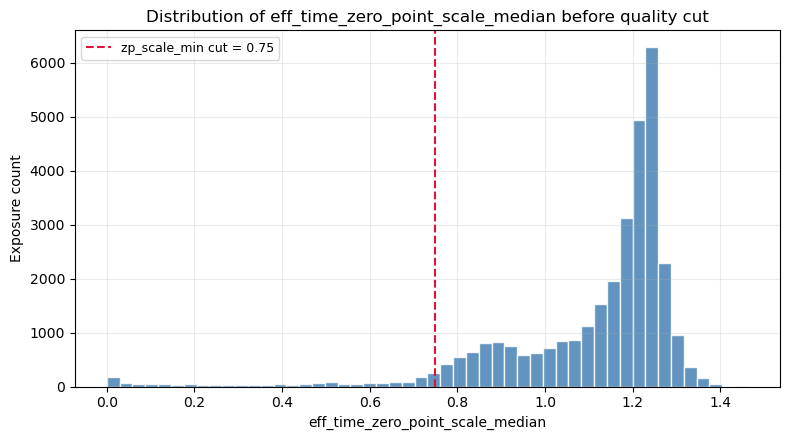

In [68]:
# Zeropoint-scale distribution BEFORE quality cuts
# Uses df_sci_wind (science exposures with wind/pointing), before df_iq_base filters.
if "df_sci_wind" not in globals():
    print("df_sci_wind not found. Re-run the join and wind-prep cells (Sections 6/7).")
else:
    zp_all = df_sci_wind["eff_time_zero_point_scale_median"]
    zp_pre = zp_all.dropna()

    print(f"Rows in df_sci_wind: {len(df_sci_wind)}")
    print(f"Rows with eff_time_zero_point_scale_median: {len(zp_pre)}")
    print(f"Rows missing eff_time_zero_point_scale_median: {zp_all.isna().sum()}")
    print(f"Median eff_time_zero_point_scale_median (pre-cut): {zp_pre.median():.4f}")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(zp_pre, bins=50, alpha=0.85, color="steelblue", edgecolor="white")

    if "IQ_CUTS" in globals() and "zp_scale_min" in IQ_CUTS:
        ax.axvline(IQ_CUTS["zp_scale_min"], color="crimson", linestyle="--", linewidth=1.5,
                   label=f"zp_scale_min cut = {IQ_CUTS['zp_scale_min']}")
        ax.legend(fontsize=9)

    ax.set_xlabel("eff_time_zero_point_scale_median")
    ax.set_ylabel("Exposure count")
    ax.set_title("Distribution of eff_time_zero_point_scale_median before quality cut")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

Rows in df_sci_wind: 33006
Rows with aos_fwhm: 32291
Rows missing aos_fwhm: 715
Median aos_fwhm (pre-cut): 0.4313


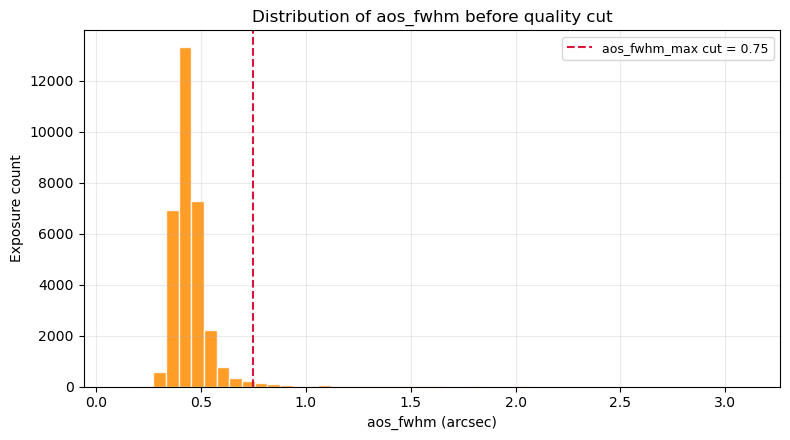

In [69]:
# AOS residual distribution BEFORE quality cuts
# Uses df_sci_wind (science exposures with wind/pointing), before df_iq_base filters.
if "df_sci_wind" not in globals():
    print("df_sci_wind not found. Re-run the join and wind-prep cells (Sections 6/7).")
else:
    aos_all = df_sci_wind["aos_fwhm"]
    aos_pre = aos_all.dropna()

    print(f"Rows in df_sci_wind: {len(df_sci_wind)}")
    print(f"Rows with aos_fwhm: {len(aos_pre)}")
    print(f"Rows missing aos_fwhm: {aos_all.isna().sum()}")
    print(f"Median aos_fwhm (pre-cut): {aos_pre.median():.4f}")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(aos_pre, bins=50, alpha=0.85, color="darkorange", edgecolor="white")

    if "IQ_CUTS" in globals() and "aos_fwhm_max" in IQ_CUTS:
        ax.axvline(IQ_CUTS["aos_fwhm_max"], color="crimson", linestyle="--", linewidth=1.5,
                   label=f"aos_fwhm_max cut = {IQ_CUTS['aos_fwhm_max']}")
        ax.legend(fontsize=9)

    ax.set_xlabel("aos_fwhm (arcsec)")
    ax.set_ylabel("Exposure count")
    ax.set_title("Distribution of aos_fwhm before quality cut")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

In [70]:
# Diagnostic: why aos_fwhm cut is large
cut = IQ_CUTS["aos_fwhm_max"]
aos = df_sci_wind["aos_fwhm"]
valid = aos.dropna()

n_total = len(df_sci_wind)
n_valid = len(valid)
n_missing = aos.isna().sum()
n_above = (valid >= cut).sum()
n_below = (valid < cut).sum()

print(f"aos_fwhm cutoff: {cut}")
print(f"valid aos_fwhm: {n_valid} / {n_total} (missing={n_missing})")
print(f"<  cutoff: {n_below} ({n_below / n_valid:.1%} of valid)")
print(f">= cutoff: {n_above} ({n_above / n_valid:.1%} of valid)")
print("\nQuantiles of aos_fwhm:")
print(valid.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())

if "band" in df_sci_wind.columns:
    band_stats = (df_sci_wind.dropna(subset=["aos_fwhm", "band"])
                  .groupby("band")["aos_fwhm"]
                  .agg(N="size", median="median", p75=lambda s: s.quantile(0.75),
                       frac_ge_cut=lambda s: (s >= cut).mean())
                  .sort_values("frac_ge_cut", ascending=False))
    print("\nBy band (fraction >= cut):")
    print(band_stats.to_string(float_format=lambda x: f"{x:.3f}"))

aos_fwhm cutoff: 0.75
valid aos_fwhm: 32291 / 33006 (missing=715)
<  cutoff: 31648 (98.0% of valid)
>= cutoff: 643 (2.0% of valid)

Quantiles of aos_fwhm:
0.10    0.369404
0.25    0.396416
0.50    0.431326
0.75    0.474627
0.90    0.532489
0.95    0.593624
0.99    0.912820

By band (fraction >= cut):
          N  median   p75  frac_ge_cut
band                                  
u       571   0.457 0.525        0.086
r      3412   0.436 0.483        0.046
g      2573   0.441 0.491        0.019
i     12673   0.416 0.457        0.017
y      6278   0.453 0.493        0.014
z      6784   0.433 0.472        0.013


## 6. Time Series Overview

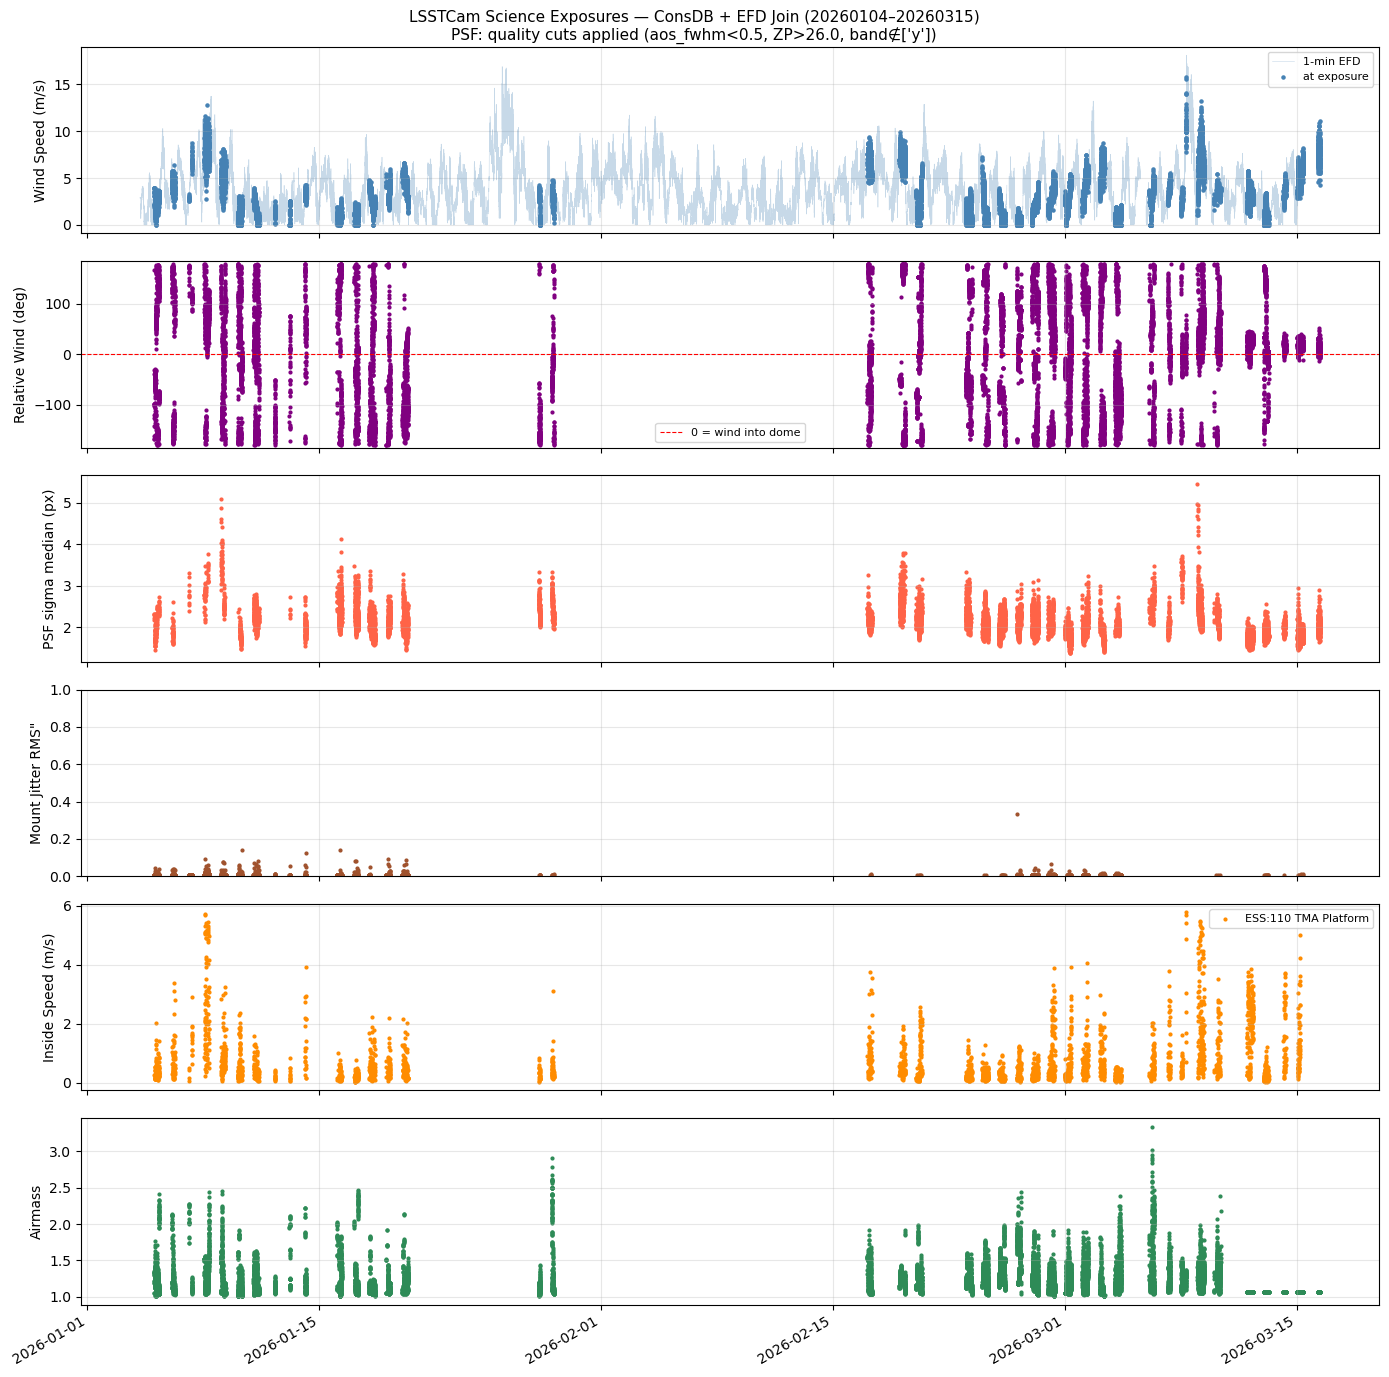

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# Wind speed: 1-min EFD background + ConsDB per-exposure dot
axes[0].plot(df_wind_1m.index, df_wind_1m["efd_wind_speed"],
             lw=0.4, color="steelblue", alpha=0.3, label="1-min EFD")
axes[0].scatter(df_sci.index, df_sci["wind_speed_best"],
                s=5, color="steelblue", label="at exposure")
axes[0].set_ylabel("Wind Speed (m/s)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Relative wind
axes[1].scatter(df_sci_wind.index, df_sci_wind["relative_wind"], s=4, color="purple")
axes[1].axhline(0, color="red", lw=0.8, ls="--", label="0 = wind into dome")
axes[1].set_ylabel("Relative Wind (deg)")
axes[1].set_ylim(-185, 185)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# PSF sigma — IQ quality cuts applied (df_iq_base)
df_psf = df_iq_base.dropna(subset=["psf_sigma_median"])
axes[2].scatter(df_psf.index, df_psf["psf_sigma_median"], s=4, color="tomato")
axes[2].set_ylabel("PSF sigma median (px)")
axes[2].grid(True, alpha=0.3)

# Mount jitter — clip to (0, 1] arcsec (uses MOUNT_JITTER_MIN/MAX from section 8)
df_mnt_ts = df_sci.dropna(subset=["mount_jitter_rms"])
df_mnt_ts = df_mnt_ts[
    (df_mnt_ts["mount_jitter_rms"] > MOUNT_JITTER_MIN) &
    (df_mnt_ts["mount_jitter_rms"] <= MOUNT_JITTER_MAX)
]
axes[3].scatter(df_mnt_ts.index, df_mnt_ts["mount_jitter_rms"], s=4, color="sienna")
axes[3].set_ylabel('Mount Jitter RMS"')
axes[3].set_ylim(MOUNT_JITTER_MIN, MOUNT_JITTER_MAX)
axes[3].grid(True, alpha=0.3)

# Inside turbulence (TMA platform)
turb_col = "turb_speed_110"
if turb_col in df_sci.columns:
    df_t = df_sci.dropna(subset=[turb_col])
    axes[4].scatter(df_t.index, df_t[turb_col], s=4, color="darkorange",
                    label="ESS:110 TMA Platform")
    axes[4].set_ylabel("Inside Speed (m/s)")
    axes[4].legend(fontsize=8)
    axes[4].grid(True, alpha=0.3)

# Airmass
axes[5].scatter(df_sci.index, df_sci["airmass"], s=4, color="seagreen")
axes[5].set_ylabel("Airmass")
axes[5].grid(True, alpha=0.3)
axes[5].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

fig.autofmt_xdate()
fig.suptitle(
    f"LSSTCam Science Exposures — ConsDB + EFD Join ({day_obs_start}–{day_obs_end})\n"
    f"PSF: quality cuts applied "
    f"(aos_fwhm<{IQ_CUTS['aos_fwhm_max']}, ZPscale>{IQ_CUTS['zp_scale_min']}, band∉{IQ_CUTS['band_exclude']})",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 7. Image Quality vs Wind Conditions

PSF σ, effective time, and seeing vs wind speed and relative pointing.

/lscratch/stalder/tmp/ipykernel_358320/265792695.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


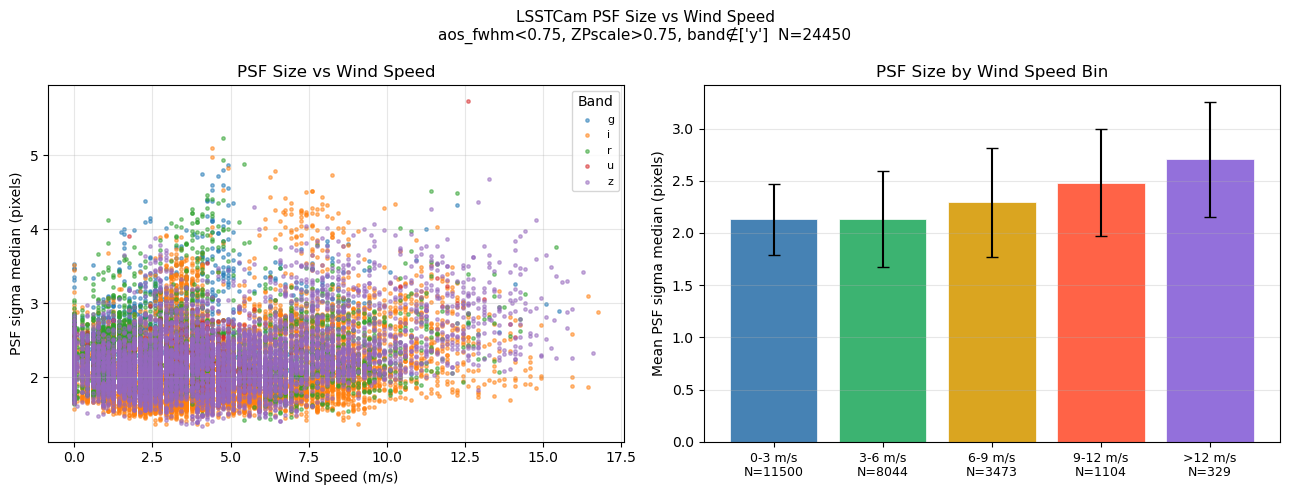

In [71]:
# PSF sigma vs wind speed — quality-cut sample (df_iq_base)
df_iq = df_iq_base.dropna(subset=["psf_sigma_median"]).copy()

if len(df_iq) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cmap = plt.cm.get_cmap("tab10")
    bands = sorted(df_iq["band"].dropna().unique())
    for i, b in enumerate(bands):
        sub = df_iq[df_iq["band"] == b]
        axes[0].scatter(sub["wind_speed_best"], sub["psf_sigma_median"],
                        s=6, alpha=0.5, color=cmap(i), label=b)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("PSF sigma median (pixels)")
    axes[0].legend(title="Band", fontsize=8)
    axes[0].set_title("PSF Size vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    by_bin = df_iq.groupby("speed_bin", observed=True)["psf_sigma_median"]
    means, stds, ns = by_bin.mean(), by_bin.std(), by_bin.count()
    x_pos = range(len(means))
    axes[1].bar(x_pos, means, yerr=stds, color=wind_speed_colors[:len(means)],
                capsize=4, edgecolor="white", linewidth=0.5)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([f"{l}\nN={n}" for l, n in zip(means.index, ns)], fontsize=9)
    axes[1].set_ylabel("Mean PSF sigma median (pixels)")
    axes[1].set_title("PSF Size by Wind Speed Bin")
    axes[1].grid(True, alpha=0.3, axis="y")

    cut_str = (f"aos_fwhm<{IQ_CUTS['aos_fwhm_max']}, "
               f"ZPscale>{IQ_CUTS['zp_scale_min']}, "
               f"band∉{IQ_CUTS['band_exclude']}  "
               f"N={len(df_iq)}")
    plt.suptitle(f"LSSTCam PSF Size vs Wind Speed\n{cut_str}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No exposures pass quality cuts + have PSF sigma")

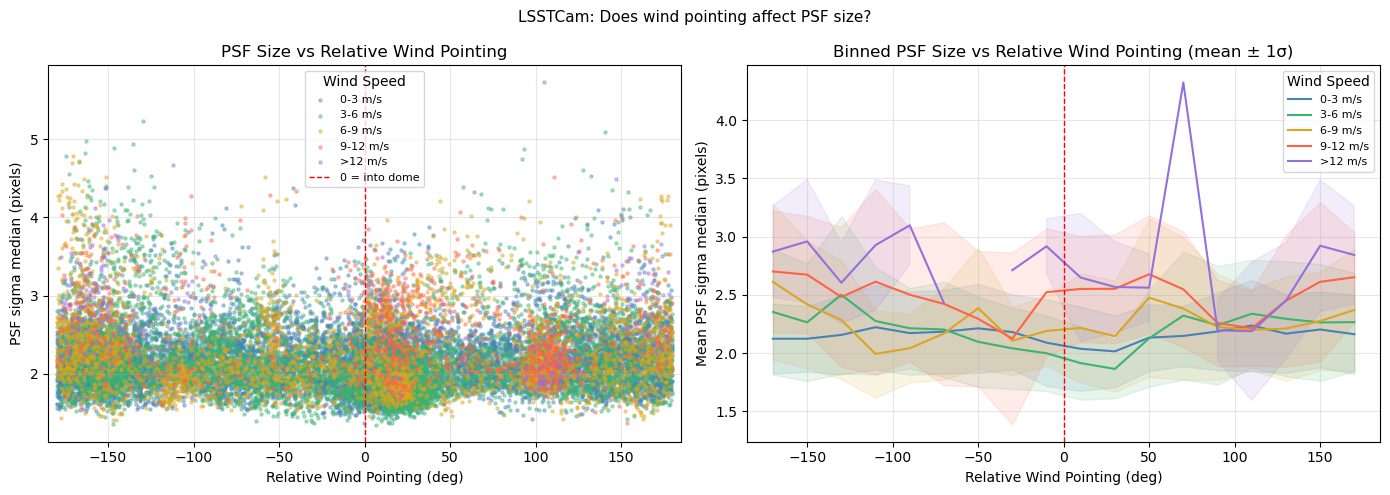

In [72]:
# PSF sigma vs relative wind pointing
if len(df_iq) > 0:
    bin_edges   = np.arange(-180, 181, 20)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: scatter PSF vs relative wind, colored by speed bin
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_iq[df_iq["speed_bin"] == blab]
        axes[0].scatter(sub["relative_wind"], sub["psf_sigma_median"],
                        s=5, alpha=0.4, color=bcol, label=blab)
    axes[0].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[0].set_xlabel("Relative Wind Pointing (deg)")
    axes[0].set_ylabel("PSF sigma median (pixels)")
    axes[0].legend(fontsize=8, title="Wind Speed")
    axes[0].set_xlim(-185, 185)
    axes[0].set_title("PSF Size vs Relative Wind Pointing")
    axes[0].grid(True, alpha=0.3)

    # Right: binned mean PSF vs relative wind, by speed bin
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_iq[df_iq["speed_bin"] == blab].dropna(subset=["relative_wind", "psf_sigma_median"])
        if sub.empty:
            continue
        bi = np.digitize(sub["relative_wind"], bin_edges) - 1
        means = [sub.loc[bi == b, "psf_sigma_median"].mean() if (bi == b).any() else np.nan
                 for b in range(len(bin_centers))]
        stds  = [sub.loc[bi == b, "psf_sigma_median"].std()  if (bi == b).any() else np.nan
                 for b in range(len(bin_centers))]
        means, stds = np.array(means), np.array(stds)
        axes[1].plot(bin_centers, means, lw=1.5, color=bcol, label=blab)
        axes[1].fill_between(bin_centers, means - stds, means + stds, alpha=0.12, color=bcol)
    axes[1].axvline(0, color="red", lw=1, ls="--")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel("Mean PSF sigma median (pixels)")
    axes[1].legend(fontsize=8, title="Wind Speed")
    axes[1].set_title("Binned PSF Size vs Relative Wind Pointing (mean ± 1σ)")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("LSSTCam: Does wind pointing affect PSF size?", fontsize=11)
    plt.tight_layout()
    plt.show()

## 7b. Donut Blur and AOS Residual vs Wind Conditions

`donut_blur_fwhm` — FWHM of the PSF blur attributed to out-of-focus donuts (AOS residual wavefront).  
`aos_fwhm` — FWHM of the PSF contribution from the AOS wavefront correction residual.  

Same plot layout as Section 7: scatter + bar by wind speed bin, then scatter + binned by relative wind pointing.

/lscratch/stalder/tmp/ipykernel_358320/1404884902.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


donut_blur_fwhm: 24448 exposures, range [0.5015, 2.2323]


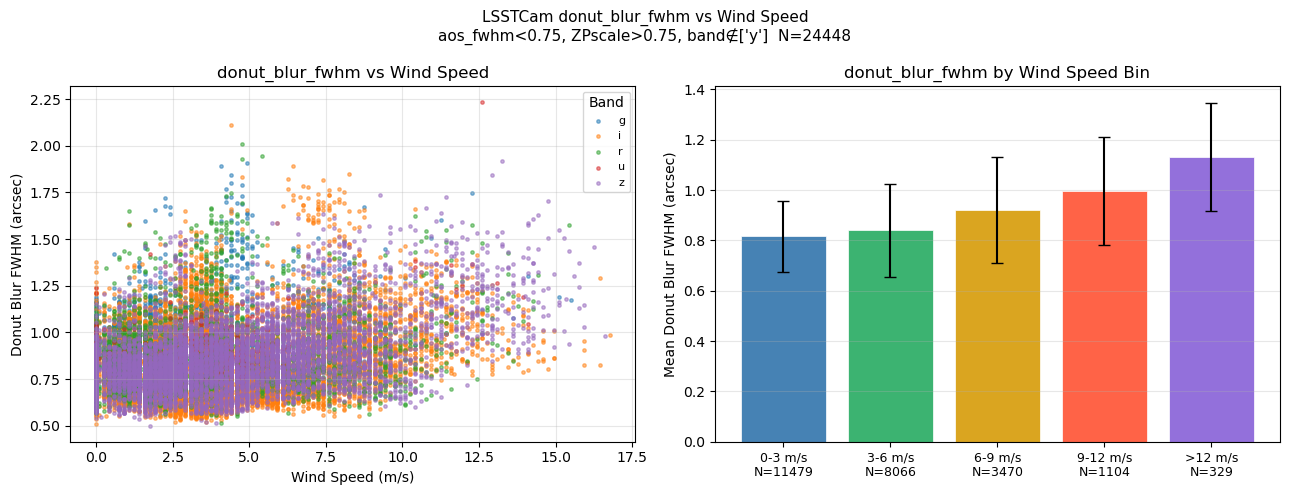

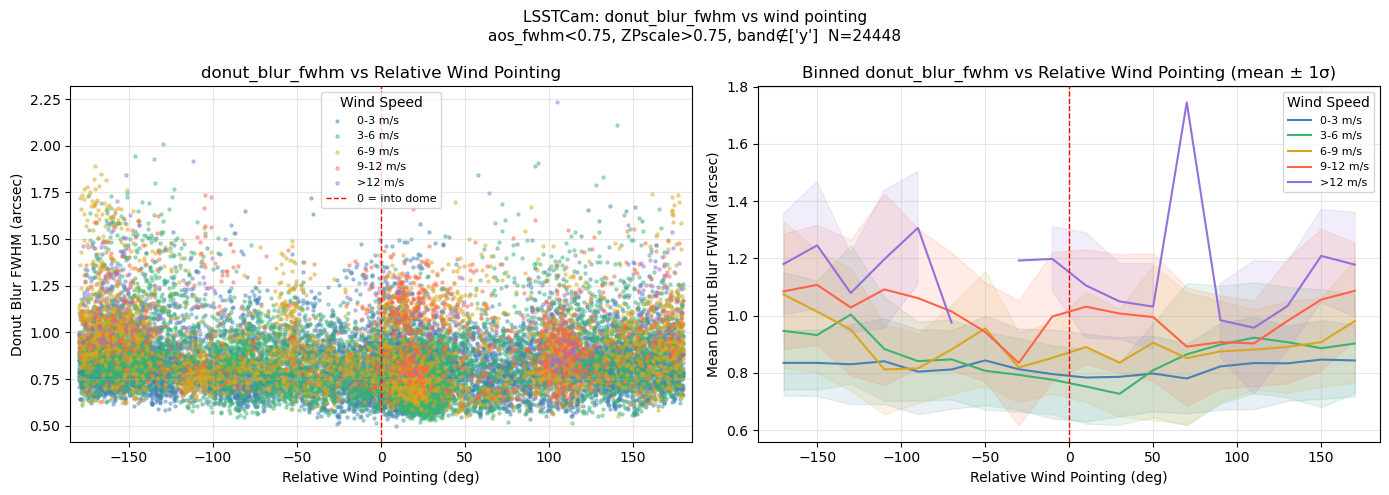

aos_fwhm: 24448 exposures, range [0.0919, 0.7497]


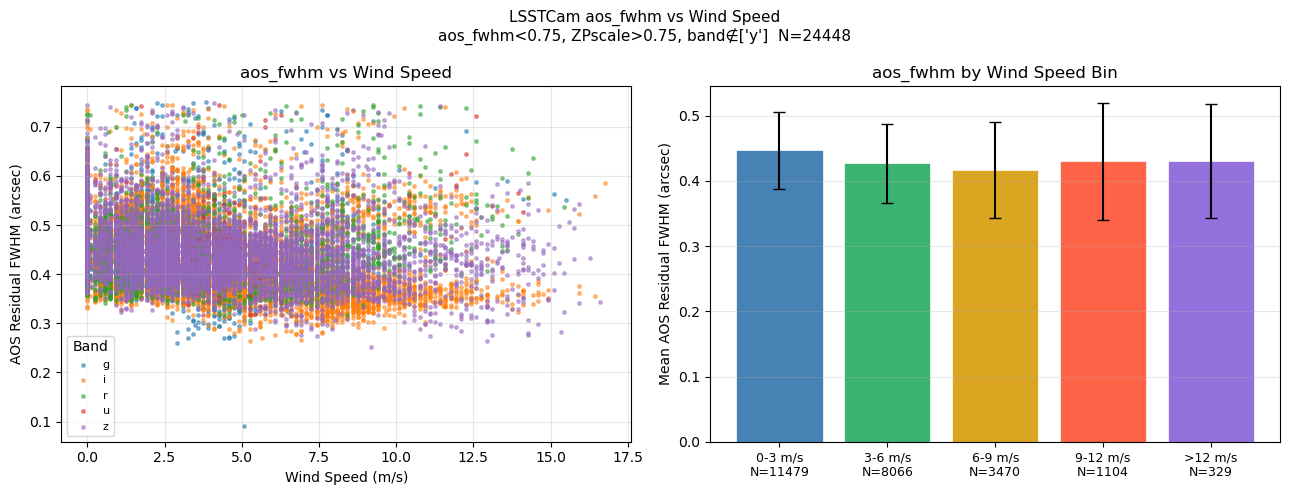

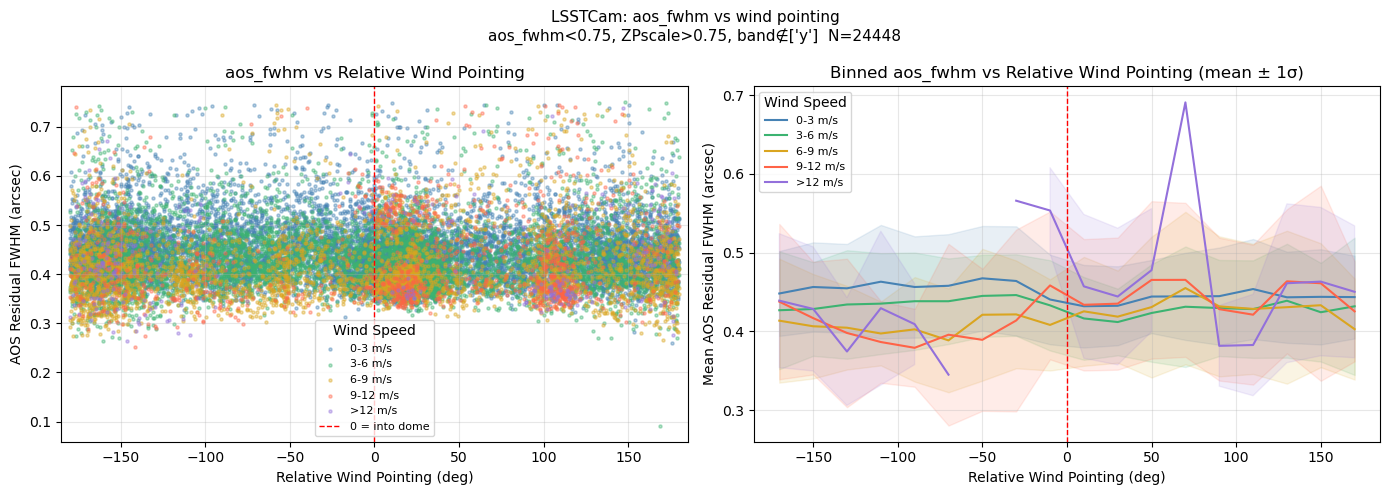

In [73]:
ao_metrics = [
    ("donut_blur_fwhm", "Donut Blur FWHM (arcsec)"),
    ("aos_fwhm",        "AOS Residual FWHM (arcsec)"),
]

# Check which metrics are present — re-run Section 2 fetch cell if any are missing
_missing = [col for col, _ in ao_metrics if col not in df_iq_base.columns]
if _missing:
    print(f"WARNING: columns not in df_iq_base: {_missing}")
    print("Re-run the ConsDB fetch cell (Section 2) then all join cells before this one.")
    ao_metrics = [(col, lbl) for col, lbl in ao_metrics if col not in _missing]

bin_edges_iq   = np.arange(-180, 181, 20)
bin_centers_iq = 0.5 * (bin_edges_iq[:-1] + bin_edges_iq[1:])
cmap = plt.cm.get_cmap("tab10")

cut_str = (f"aos_fwhm<{IQ_CUTS['aos_fwhm_max']}, "
           f"ZPscale>{IQ_CUTS['zp_scale_min']}, "
           f"band∉{IQ_CUTS['band_exclude']}")

for col, ylabel in ao_metrics:
    df_m = df_iq_base.dropna(subset=[col]).copy()

    if df_m.empty:
        print(f"{col}: no data after quality cuts")
        continue

    print(f"{col}: {len(df_m)} exposures, "
          f"range [{df_m[col].min():.4f}, {df_m[col].max():.4f}]")

    # ── Plot 1: vs wind speed ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    bands = sorted(df_m["band"].dropna().unique())
    for i, b in enumerate(bands):
        sub = df_m[df_m["band"] == b]
        axes[0].scatter(sub["wind_speed_best"], sub[col],
                        s=6, alpha=0.5, color=cmap(i), label=b)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Band", fontsize=8)
    axes[0].set_title(f"{col} vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    by_bin = df_m.groupby("speed_bin", observed=True)[col]
    means, stds, ns = by_bin.mean(), by_bin.std(), by_bin.count()
    x_pos = range(len(means))
    axes[1].bar(x_pos, means, yerr=stds, color=wind_speed_colors[:len(means)],
                capsize=4, edgecolor="white", linewidth=0.5)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([f"{l}\nN={n}" for l, n in zip(means.index, ns)], fontsize=9)
    axes[1].set_ylabel(f"Mean {ylabel}")
    axes[1].set_title(f"{col} by Wind Speed Bin")
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.suptitle(f"LSSTCam {col} vs Wind Speed\n{cut_str}  N={len(df_m)}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: vs relative wind pointing ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_m[df_m["speed_bin"] == blab]
        axes[0].scatter(sub["relative_wind"], sub[col],
                        s=5, alpha=0.4, color=bcol, label=blab)
    axes[0].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[0].set_xlabel("Relative Wind Pointing (deg)")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(fontsize=8, title="Wind Speed")
    axes[0].set_xlim(-185, 185)
    axes[0].set_title(f"{col} vs Relative Wind Pointing")
    axes[0].grid(True, alpha=0.3)

    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_m[df_m["speed_bin"] == blab].dropna(subset=["relative_wind", col])
        if sub.empty:
            continue
        bi    = np.digitize(sub["relative_wind"], bin_edges_iq) - 1
        means = np.array([sub.loc[bi == b, col].mean() if (bi == b).any() else np.nan
                          for b in range(len(bin_centers_iq))])
        stds  = np.array([sub.loc[bi == b, col].std()  if (bi == b).any() else np.nan
                          for b in range(len(bin_centers_iq))])
        axes[1].plot(bin_centers_iq, means, lw=1.5, color=bcol, label=blab)
        axes[1].fill_between(bin_centers_iq, means - stds, means + stds,
                             alpha=0.12, color=bcol)
    axes[1].axvline(0, color="red", lw=1, ls="--")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel(f"Mean {ylabel}")
    axes[1].legend(fontsize=8, title="Wind Speed")
    axes[1].set_title(f"Binned {col} vs Relative Wind Pointing (mean ± 1σ)")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LSSTCam: {col} vs wind pointing\n{cut_str}  N={len(df_m)}", fontsize=11)
    plt.tight_layout()
    plt.show()

## 7c. IQ vs Inside Wind Speed (Top-Ring Anemometers)

Mean of the four top-ring ESS sensors (indices 123–126) as a proxy for dome seeing
turbulence.  Same quality cuts (`df_iq_base`) as Sections 7 and 7b.

Top-ring sensors used: ['turb_speed_123', 'turb_speed_124', 'turb_speed_125', 'turb_speed_126']
Exposures with inside speed: 8747 / 25153

Inside speed bin counts:


inside_speed_bin
0–0.5 m/s    4402
0.5–1 m/s    2289
1–2 m/s      1297
2–4 m/s       652
>4 m/s        107
Name: count, dtype: int64


psf_sigma_median: 8476 exposures, inside speed range [0.033, 7.408] m/s


/lscratch/stalder/tmp/ipykernel_358320/3500065722.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap           = plt.cm.get_cmap("tab10")


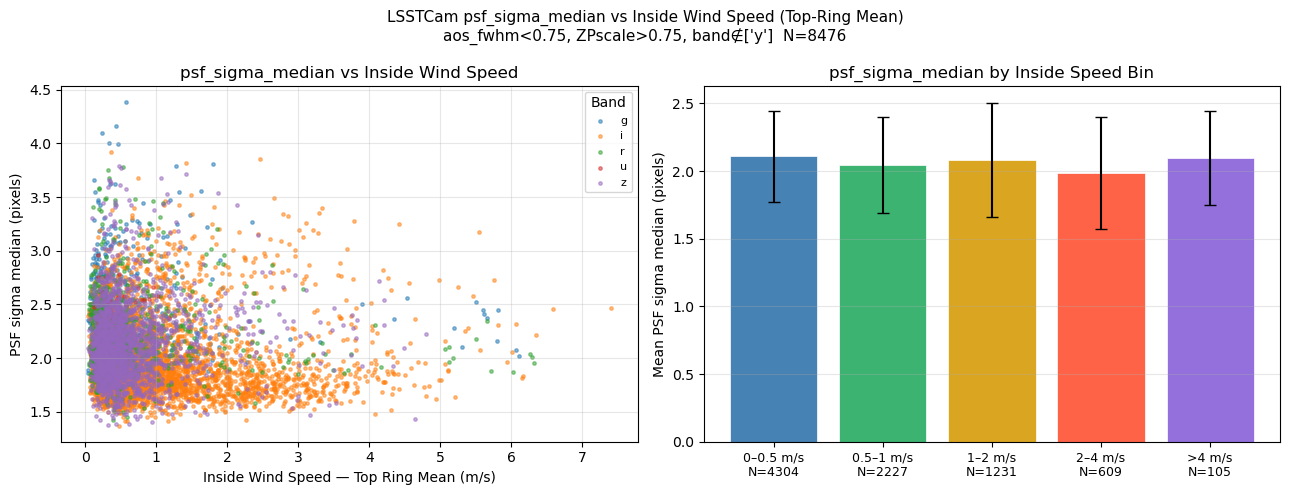

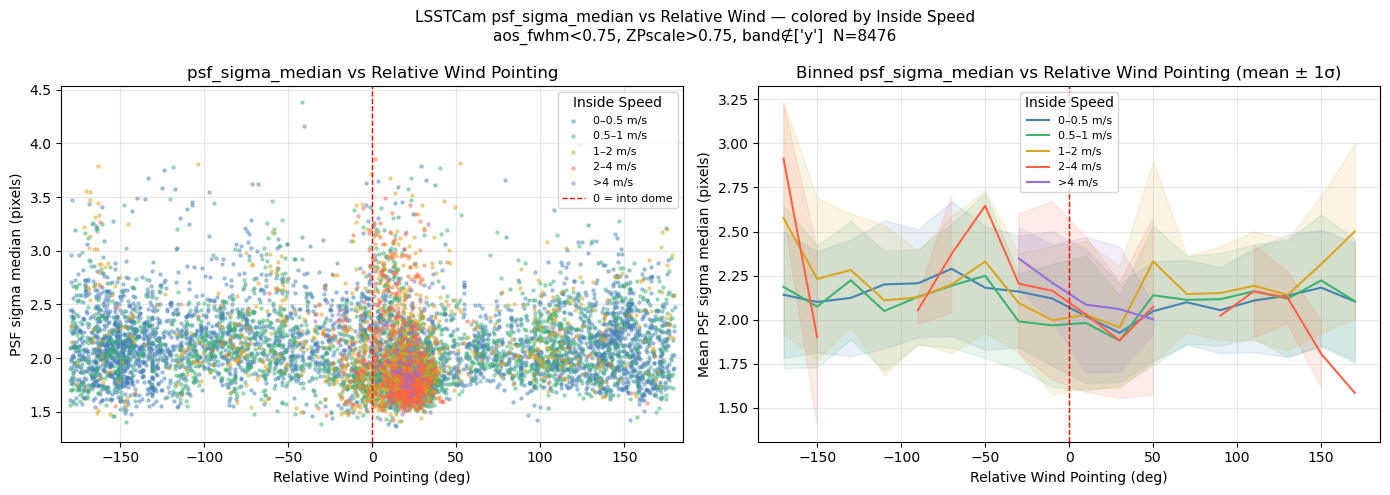


donut_blur_fwhm: 8456 exposures, inside speed range [0.033, 7.408] m/s


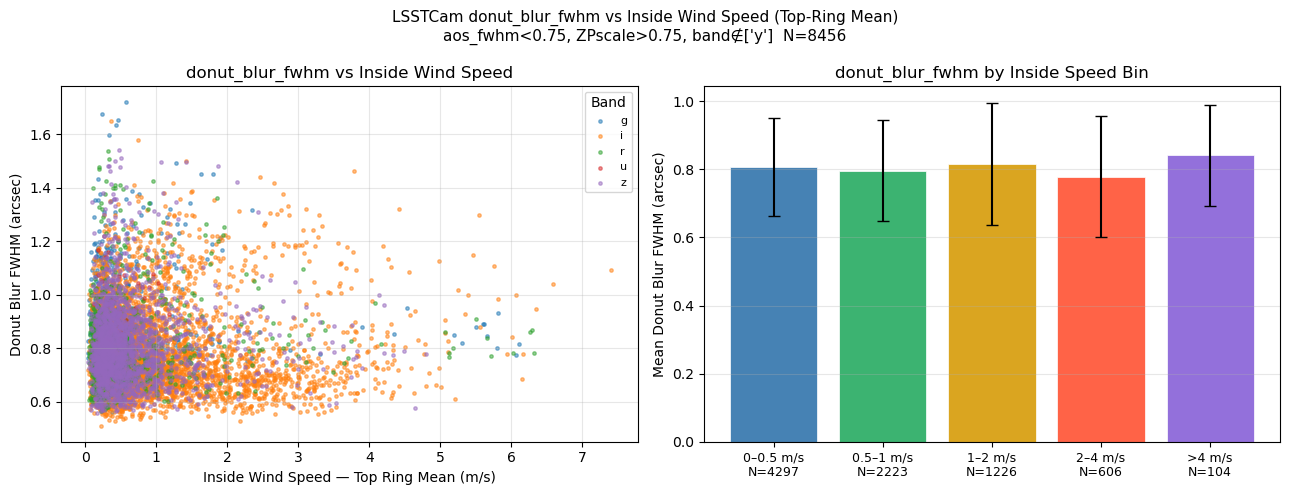

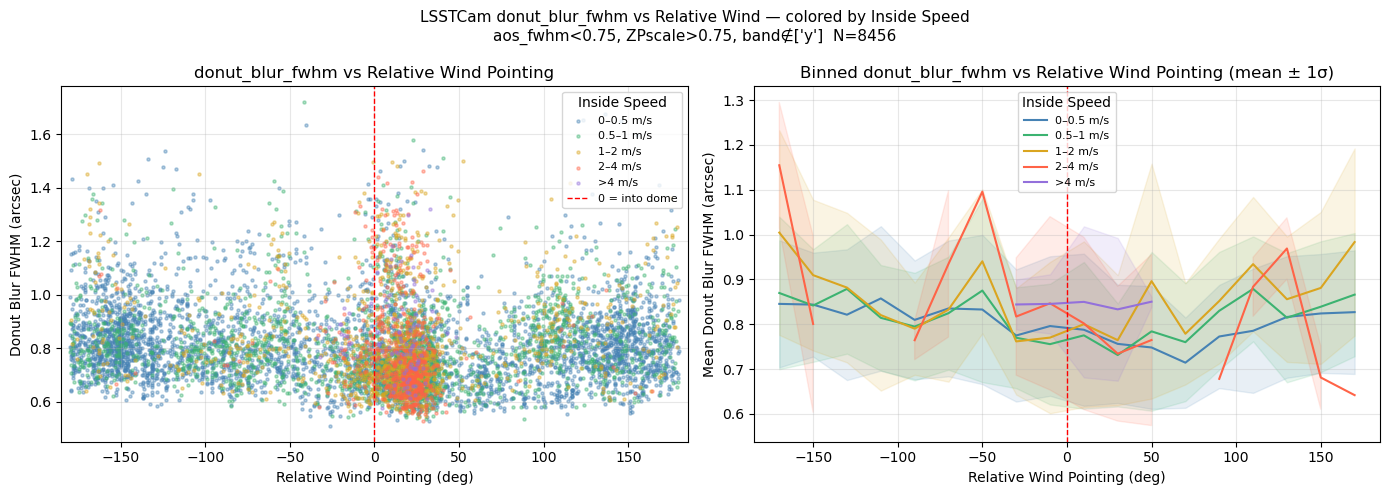


aos_fwhm: 8456 exposures, inside speed range [0.033, 7.408] m/s


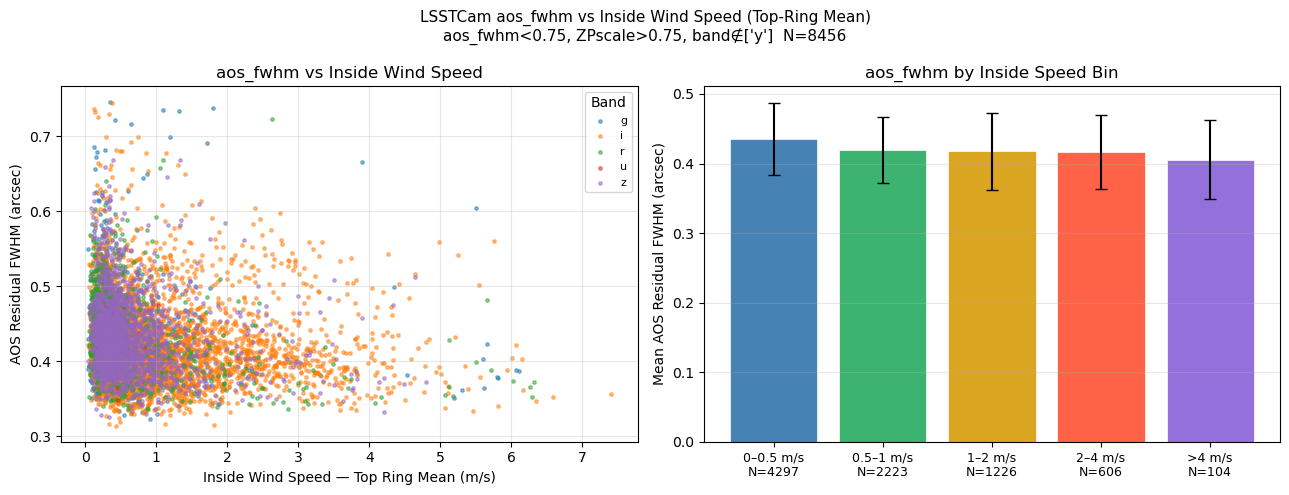

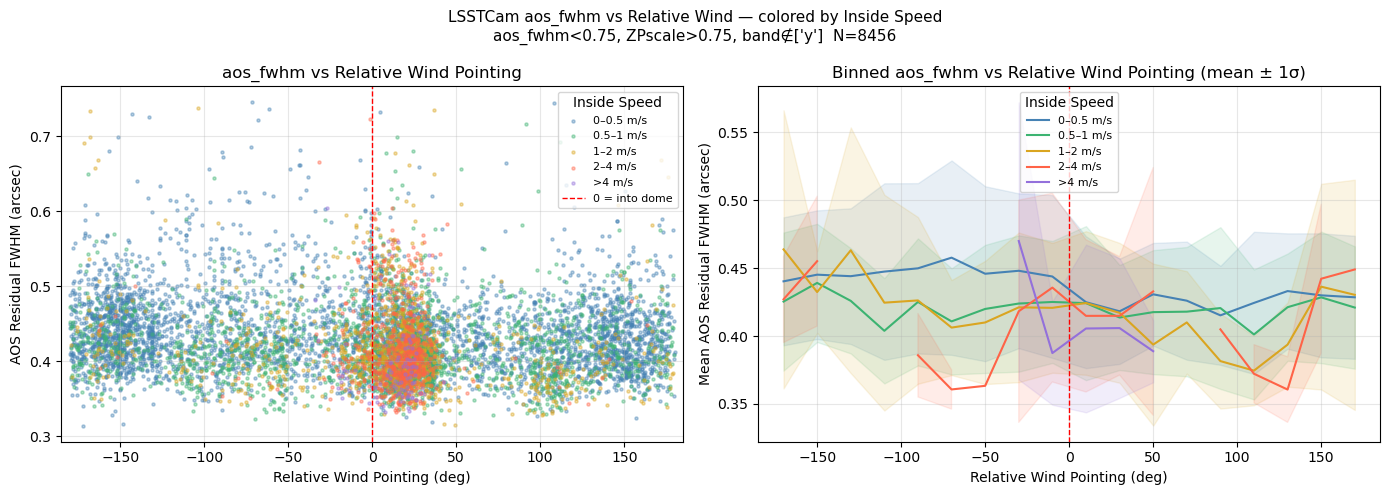

In [74]:
top_ring_cols = [f"turb_speed_{idx}" for idx in [123, 124, 125, 126]]
available_tr  = [c for c in top_ring_cols if c in df_iq_base.columns]

if not available_tr:
    print("No top-ring turbulence columns in df_iq_base — re-run EFD fetch and join cells.")
else:
    # Mean of available top-ring sensors (NaN if ALL are NaN for that row)
    df_iq_tr = df_iq_base.copy()
    df_iq_tr["inside_speed_mean"] = df_iq_tr[available_tr].mean(axis=1, skipna=True)
    df_iq_tr.loc[df_iq_tr[available_tr].isna().all(axis=1), "inside_speed_mean"] = np.nan

    # Bin by inside speed (lower thresholds than outside — dome turbulence is calmer)
    inside_bins   = [0, 0.5, 1.0, 2.0, 4.0, np.inf]
    inside_labels = ["0–0.5 m/s", "0.5–1 m/s", "1–2 m/s", "2–4 m/s", ">4 m/s"]
    inside_colors = ["steelblue", "mediumseagreen", "goldenrod", "tomato", "mediumpurple"]

    df_iq_tr["inside_speed_bin"] = pd.cut(
        df_iq_tr["inside_speed_mean"],
        bins=inside_bins, labels=inside_labels, right=False,
    )

    print(f"Top-ring sensors used: {available_tr}")
    print(f"Exposures with inside speed: {df_iq_tr['inside_speed_mean'].notna().sum()} / {len(df_iq_tr)}")
    print("\nInside speed bin counts:")
    display(df_iq_tr["inside_speed_bin"].value_counts().sort_index())

    bin_edges_rw   = np.arange(-180, 181, 20)
    bin_centers_rw = 0.5 * (bin_edges_rw[:-1] + bin_edges_rw[1:])
    cmap           = plt.cm.get_cmap("tab10")

    iq_metrics = [
        ("psf_sigma_median", "PSF sigma median (pixels)"),
        ("donut_blur_fwhm",  "Donut Blur FWHM (arcsec)"),
        ("aos_fwhm",         "AOS Residual FWHM (arcsec)"),
    ]
    # Skip metrics not in the DataFrame
    iq_metrics = [(col, lbl) for col, lbl in iq_metrics if col in df_iq_tr.columns]

    cut_str = (f"aos_fwhm<{IQ_CUTS['aos_fwhm_max']}, "
               f"ZPscale>{IQ_CUTS['zp_scale_min']}, "
               f"band∉{IQ_CUTS['band_exclude']}")

    for col, ylabel in iq_metrics:
        df_m = df_iq_tr.dropna(subset=[col, "inside_speed_mean"]).copy()
        if df_m.empty:
            print(f"{col}: no data")
            continue
        print(f"\n{col}: {len(df_m)} exposures, "
              f"inside speed range [{df_m['inside_speed_mean'].min():.3f}, "
              f"{df_m['inside_speed_mean'].max():.3f}] m/s")

        # ── Plot 1: vs inside wind speed ──────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        bands = sorted(df_m["band"].dropna().unique())
        for i, b in enumerate(bands):
            sub = df_m[df_m["band"] == b]
            axes[0].scatter(sub["inside_speed_mean"], sub[col],
                            s=6, alpha=0.5, color=cmap(i), label=b)
        axes[0].set_xlabel("Inside Wind Speed — Top Ring Mean (m/s)")
        axes[0].set_ylabel(ylabel)
        axes[0].legend(title="Band", fontsize=8)
        axes[0].set_title(f"{col} vs Inside Wind Speed")
        axes[0].grid(True, alpha=0.3)

        by_bin  = df_m.groupby("inside_speed_bin", observed=True)[col]
        means, stds, ns = by_bin.mean(), by_bin.std(), by_bin.count()
        x_pos = range(len(means))
        axes[1].bar(x_pos, means, yerr=stds, color=inside_colors[:len(means)],
                    capsize=4, edgecolor="white", linewidth=0.5)
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(
            [f"{l}\nN={n}" for l, n in zip(means.index, ns)], fontsize=9
        )
        axes[1].set_ylabel(f"Mean {ylabel}")
        axes[1].set_title(f"{col} by Inside Speed Bin")
        axes[1].grid(True, alpha=0.3, axis="y")

        plt.suptitle(
            f"LSSTCam {col} vs Inside Wind Speed (Top-Ring Mean)\n{cut_str}  N={len(df_m)}",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()

        # ── Plot 2: vs relative wind pointing, colored by inside speed bin ────
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for blab, bcol in zip(inside_labels, inside_colors):
            sub = df_m[df_m["inside_speed_bin"] == blab]
            axes[0].scatter(sub["relative_wind"], sub[col],
                            s=5, alpha=0.4, color=bcol, label=blab)
        axes[0].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
        axes[0].set_xlabel("Relative Wind Pointing (deg)")
        axes[0].set_ylabel(ylabel)
        axes[0].legend(fontsize=8, title="Inside Speed")
        axes[0].set_xlim(-185, 185)
        axes[0].set_title(f"{col} vs Relative Wind Pointing")
        axes[0].grid(True, alpha=0.3)

        for blab, bcol in zip(inside_labels, inside_colors):
            sub = df_m[df_m["inside_speed_bin"] == blab].dropna(subset=["relative_wind"])
            if sub.empty:
                continue
            bi    = np.digitize(sub["relative_wind"], bin_edges_rw) - 1
            means = np.array([sub.loc[bi == b, col].mean()
                              if (bi == b).any() else np.nan
                              for b in range(len(bin_centers_rw))])
            stds  = np.array([sub.loc[bi == b, col].std()
                              if (bi == b).any() else np.nan
                              for b in range(len(bin_centers_rw))])
            axes[1].plot(bin_centers_rw, means, lw=1.5, color=bcol, label=blab)
            axes[1].fill_between(bin_centers_rw, means - stds, means + stds,
                                 alpha=0.12, color=bcol)
        axes[1].axvline(0, color="red", lw=1, ls="--")
        axes[1].set_xlabel("Relative Wind Pointing (deg)")
        axes[1].set_ylabel(f"Mean {ylabel}")
        axes[1].legend(fontsize=8, title="Inside Speed")
        axes[1].set_title(f"Binned {col} vs Relative Wind Pointing (mean ± 1σ)")
        axes[1].set_xlim(-185, 185)
        axes[1].grid(True, alpha=0.3)

        plt.suptitle(
            f"LSSTCam {col} vs Relative Wind — colored by Inside Speed\n{cut_str}  N={len(df_m)}",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()

## 8. Mount Jitter vs Wind

`exposure_quicklook.mount_jitter_rms` and `mount_motion_image_degradation` measure
TMA tracking performance during the shutter-open window.  We test whether wind speed
or relative wind pointing predicts mount jitter.

Mount jitter rows: 14056 total → 14040 after clip (0.0, 1.0] arcsec (removed 16)


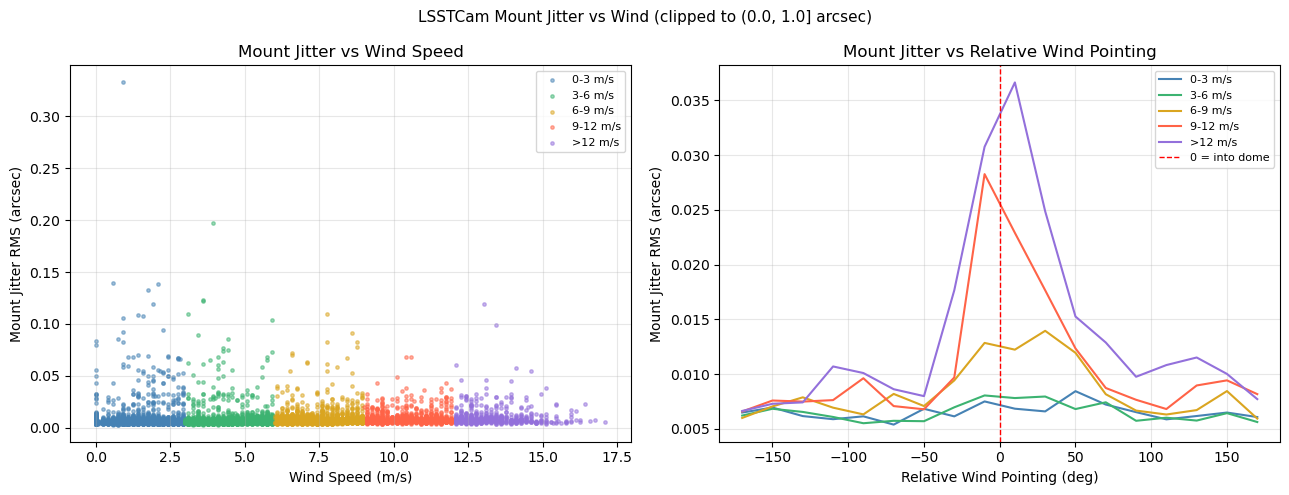

In [75]:
df_mnt_w = df_sci_wind.dropna(subset=["mount_jitter_rms"]).copy()
n_raw = len(df_mnt_w)
df_mnt_w = df_mnt_w[
    (df_mnt_w["mount_jitter_rms"] > MOUNT_JITTER_MIN) &
    (df_mnt_w["mount_jitter_rms"] <= MOUNT_JITTER_MAX)
]
print(f"Mount jitter rows: {n_raw} total → {len(df_mnt_w)} after clip "
      f"({MOUNT_JITTER_MIN}, {MOUNT_JITTER_MAX}] arcsec "
      f"(removed {n_raw - len(df_mnt_w)})")

if len(df_mnt_w) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: mount jitter vs wind speed
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_mnt_w[df_mnt_w["speed_bin"] == blab]
        axes[0].scatter(sub["wind_speed_best"], sub["mount_jitter_rms"],
                        s=6, alpha=0.5, color=bcol, label=blab)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("Mount Jitter RMS (arcsec)")
#    axes[0].set_ylim(MOUNT_JITTER_MIN, MOUNT_JITTER_MAX)
    axes[0].legend(fontsize=8)
    axes[0].set_title("Mount Jitter vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    # Binned vs relative wind
    bin_edges_rel   = np.arange(-180, 181, 20)
    bin_centers_rel = 0.5 * (bin_edges_rel[:-1] + bin_edges_rel[1:])
    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_mnt_w[df_mnt_w["speed_bin"] == blab].dropna(subset=["relative_wind"])
        if sub.empty:
            continue
        bi    = np.digitize(sub["relative_wind"], bin_edges_rel) - 1
        means = [sub.loc[bi == b, "mount_jitter_rms"].mean() if (bi == b).any() else np.nan
                 for b in range(len(bin_centers_rel))]
        axes[1].plot(bin_centers_rel, np.array(means), lw=1.5, color=bcol, label=blab)
    axes[1].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel("Mount Jitter RMS (arcsec)")
#    axes[1].set_ylim(MOUNT_JITTER_MIN, MOUNT_JITTER_MAX)
    axes[1].legend(fontsize=8)
    axes[1].set_title("Mount Jitter vs Relative Wind Pointing")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f"LSSTCam Mount Jitter vs Wind (clipped to ({MOUNT_JITTER_MIN}, {MOUNT_JITTER_MAX}] arcsec)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No mount jitter data in window after clipping")

## 9. Mount Motion Image Degradation vs Wind

`mount_motion_image_degradation` is the total image blur (arcsec) due to TMA tracking
errors, combining azimuth (`_az`), elevation (`_el`), and rotator (`_rot`) contributions.
Same 0–1 arcsec clip as mount jitter above.

In [1]:
df_mmid = df_sci_wind.dropna(subset=["mount_motion_image_degradation"]).copy()
n_raw = len(df_mmid)
df_mmid = df_mmid[
    (df_mmid["mount_motion_image_degradation"] > MOUNT_JITTER_MIN) &
    (df_mmid["mount_motion_image_degradation"] <= MOUNT_JITTER_MAX)
]
print(f"Mount motion rows: {n_raw} total → {len(df_mmid)} after clip "
      f"({MOUNT_JITTER_MIN}, {MOUNT_JITTER_MAX}] arcsec "
      f"(removed {n_raw - len(df_mmid)})")

if len(df_mmid) > 0:
    bin_edges_rel   = np.arange(-180, 181, 20)
    bin_centers_rel = 0.5 * (bin_edges_rel[:-1] + bin_edges_rel[1:])

    # ── Plot 1: total degradation vs wind speed + relative wind ───────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_mmid[df_mmid["speed_bin"] == blab]
        axes[0].scatter(sub["wind_speed_best"], sub["mount_motion_image_degradation"],
                        s=6, alpha=0.5, color=bcol, label=blab)
    axes[0].set_xlabel("Wind Speed (m/s)")
    axes[0].set_ylabel("Mount Motion Image Degradation (arcsec)")
    axes[0].legend(fontsize=8)
    axes[0].set_title("Mount Motion Degradation vs Wind Speed")
    axes[0].grid(True, alpha=0.3)

    for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
        sub = df_mmid[df_mmid["speed_bin"] == blab].dropna(subset=["relative_wind"])
        if sub.empty:
            continue
        bi    = np.digitize(sub["relative_wind"], bin_edges_rel) - 1
        means = [sub.loc[bi == b, "mount_motion_image_degradation"].mean()
                 if (bi == b).any() else np.nan
                 for b in range(len(bin_centers_rel))]
        axes[1].plot(bin_centers_rel, np.array(means), lw=1.5, color=bcol, label=blab)
    axes[1].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
    axes[1].set_xlabel("Relative Wind Pointing (deg)")
    axes[1].set_ylabel("Mount Motion Image Degradation (arcsec)")
    axes[1].legend(fontsize=8)
    axes[1].set_title("Mount Motion Degradation vs Relative Wind Pointing")
    axes[1].set_xlim(-185, 185)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f"LSSTCam Mount Motion Image Degradation vs Wind "
        f"(clipped to ({MOUNT_JITTER_MIN}, {MOUNT_JITTER_MAX}] arcsec)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

    # ── Plot 2: az / el / rot breakdown ───────────────────────────────────────
    components = [
        ("mount_motion_image_degradation_az",  "Azimuth",  "steelblue"),
        ("mount_motion_image_degradation_el",  "Elevation","seagreen"),
        ("mount_motion_image_degradation_rot", "Rotator",  "darkorange"),
    ]
    # Only keep components that are present and have data
    components = [(col, lbl, c) for col, lbl, c in components
                  if col in df_mmid.columns and df_mmid[col].notna().any()]

    if components:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        for col, lbl, color in components:
            sub = df_mmid.dropna(subset=[col])
            axes[0].scatter(sub["wind_speed_best"], sub[col],
                            s=5, alpha=0.4, color=color, label=lbl)
        axes[0].set_xlabel("Wind Speed (m/s)")
        axes[0].set_ylabel("Image Degradation (arcsec)")
        axes[0].legend(fontsize=9)
        axes[0].set_title("Az / El / Rot Contributions vs Wind Speed")
        axes[0].grid(True, alpha=0.3)

        for col, lbl, color in components:
            sub = df_mmid.dropna(subset=[col, "relative_wind"])
            bi    = np.digitize(sub["relative_wind"], bin_edges_rel) - 1
            means = [sub.loc[bi == b, col].mean() if (bi == b).any() else np.nan
                     for b in range(len(bin_centers_rel))]
            axes[1].plot(bin_centers_rel, np.array(means), lw=1.5,
                         color=color, label=lbl)
        axes[1].axvline(0, color="red", lw=1, ls="--", label="0 = into dome")
        axes[1].set_xlabel("Relative Wind Pointing (deg)")
        axes[1].set_ylabel("Image Degradation (arcsec)")
        axes[1].legend(fontsize=9)
        axes[1].set_title("Az / El / Rot Contributions vs Relative Wind")
        axes[1].set_xlim(-185, 185)
        axes[1].grid(True, alpha=0.3)

        plt.suptitle("Mount Motion Degradation Components vs Wind", fontsize=11)
        plt.tight_layout()
        plt.show()
else:
    print("No mount motion data in window after clipping")

NameError: name 'df_sci_wind' is not defined

## 10. Mirror Motion vs Wind (M1M3 IMS, Hardpoints, M2)

Per-exposure **std** of each DOF/hardpoint is the dynamic mirror motion signal
(how much the mirror moved *during* the exposure).  Per-exposure **mean** shows
the static deflection.

Three topics:
- `MTM1M3.imsData` — M1M3 rigid-body position (x/y/z µm, xRot/yRot/zRot arcsec)
- `MTM1M3.hardpointActuatorData` — 6 hardpoint forces (N)
- `MTM2.position` — M2 rigid-body position (x/y/z µm, xRot/yRot/zRot arcsec)

Each figure: sub-panels per DOF/hardpoint, showing std during exposure
vs wind speed (scatter) and vs relative wind pointing (binned mean).

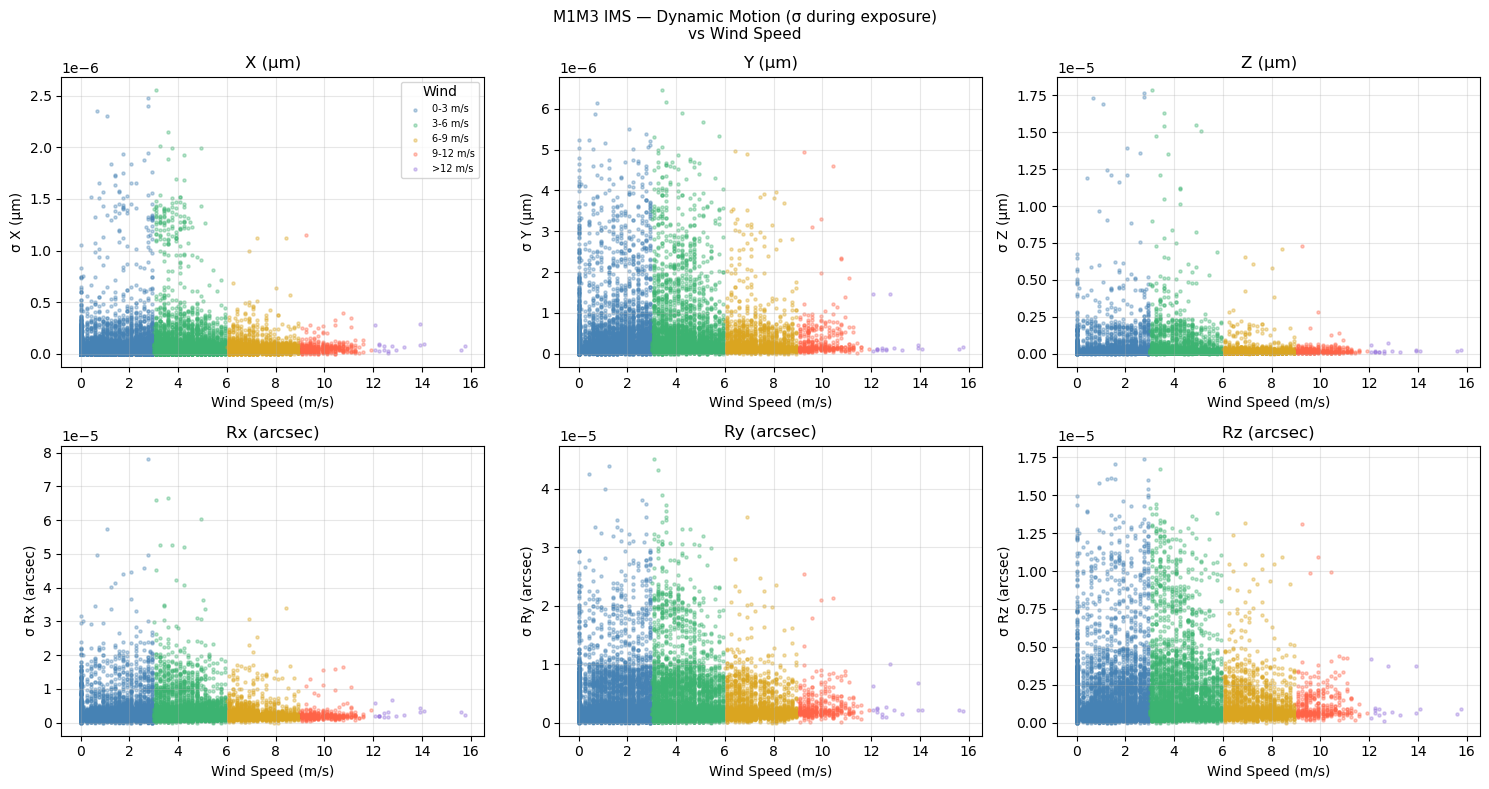

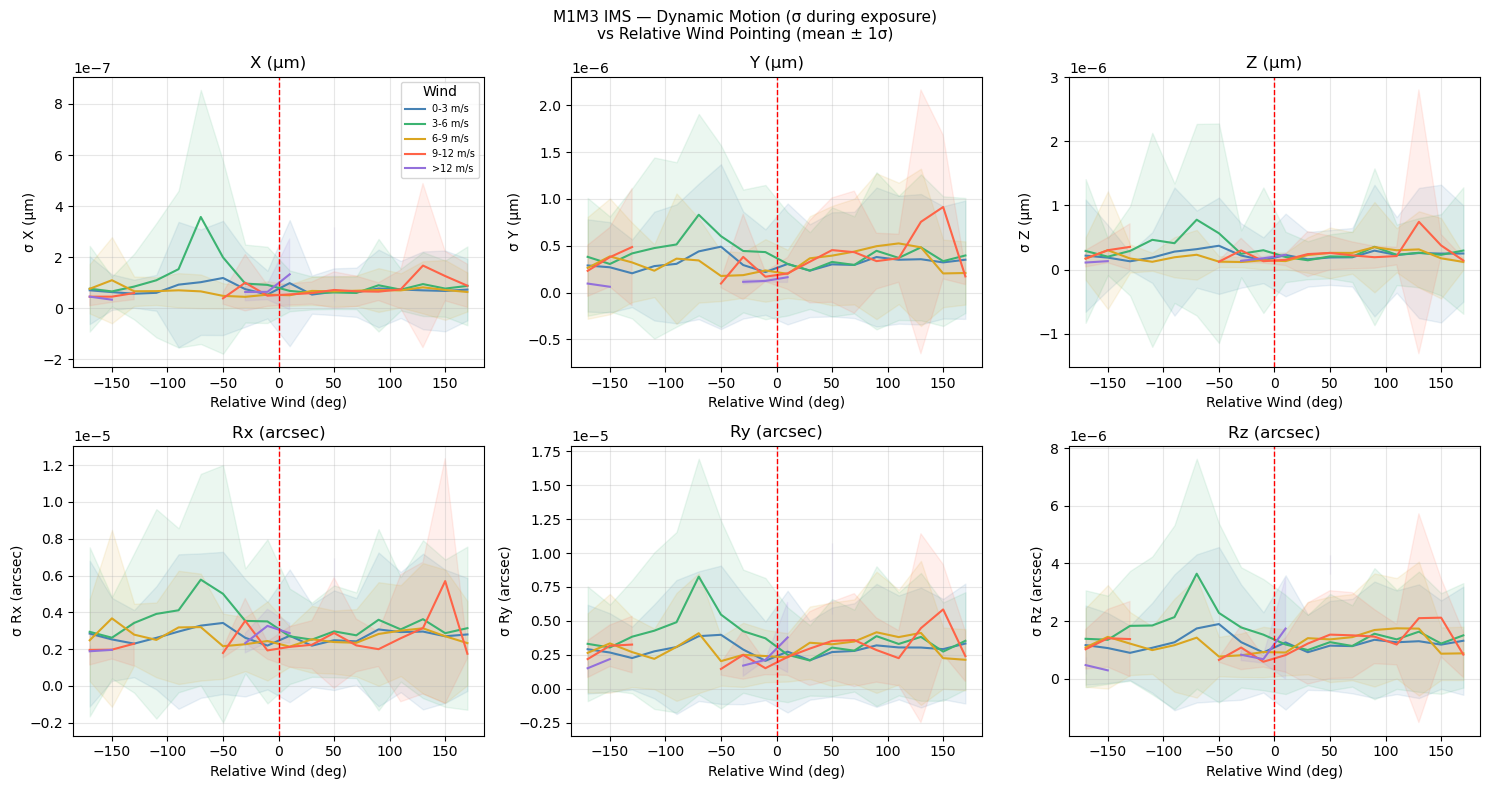

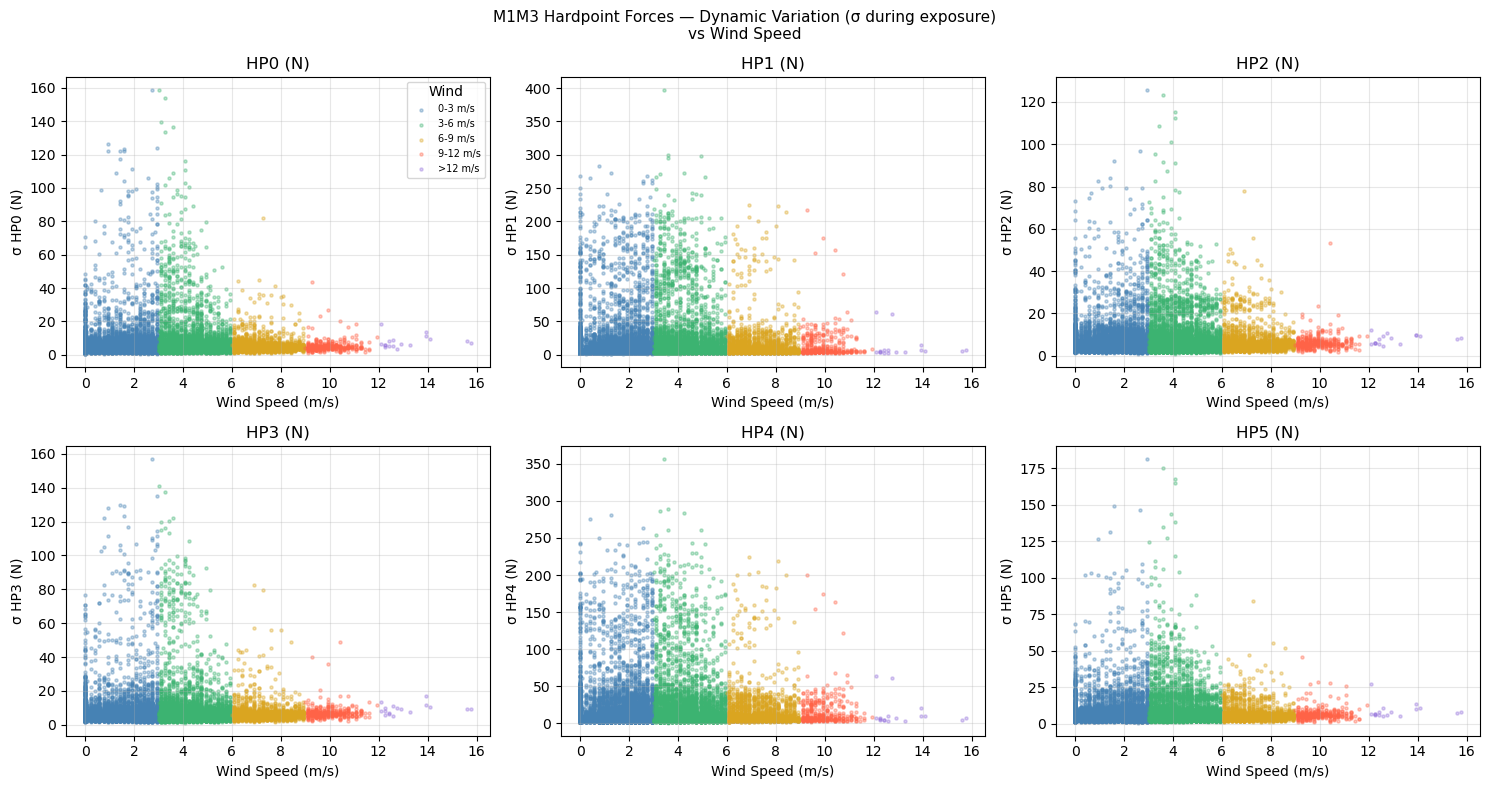

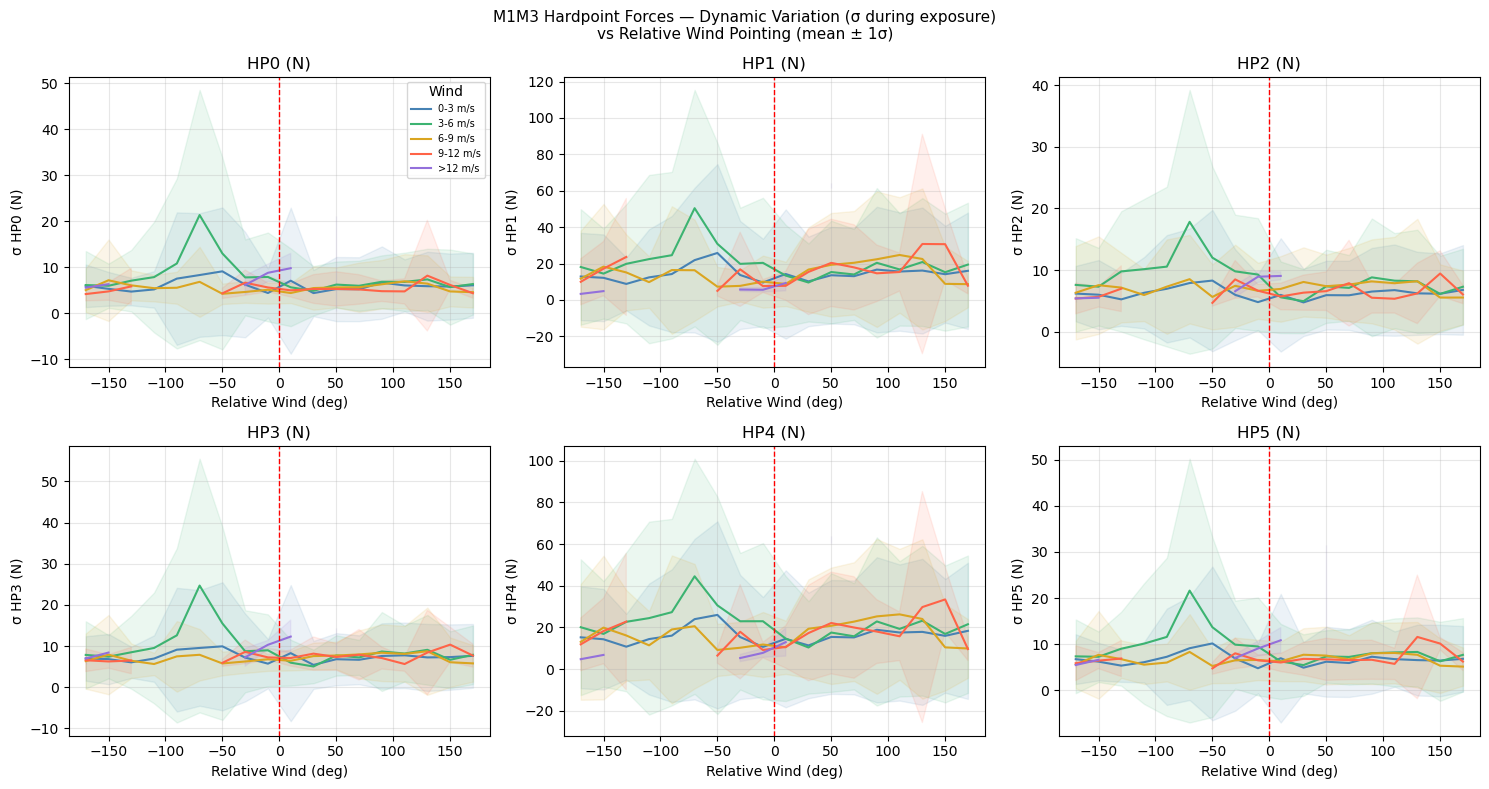

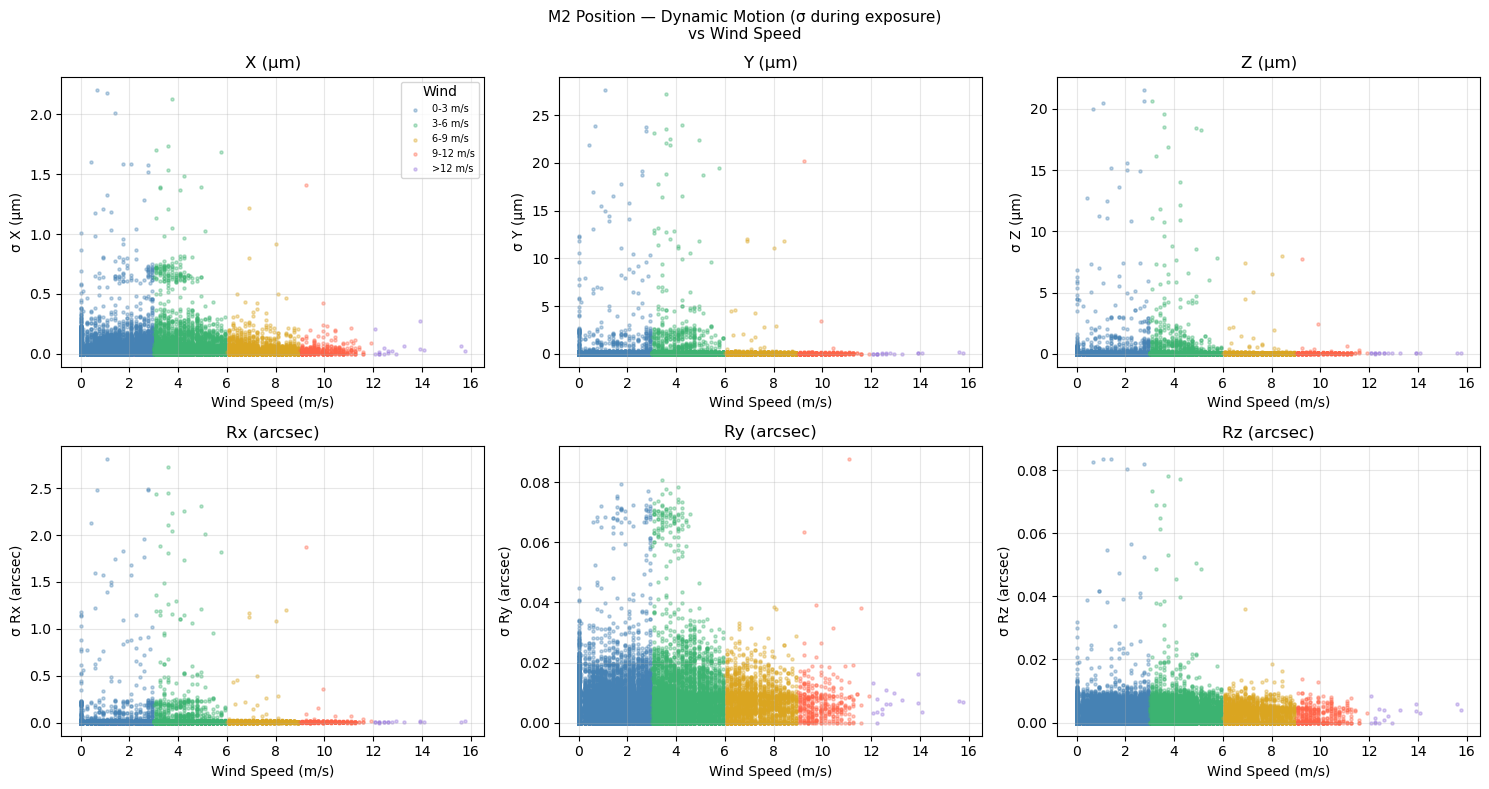

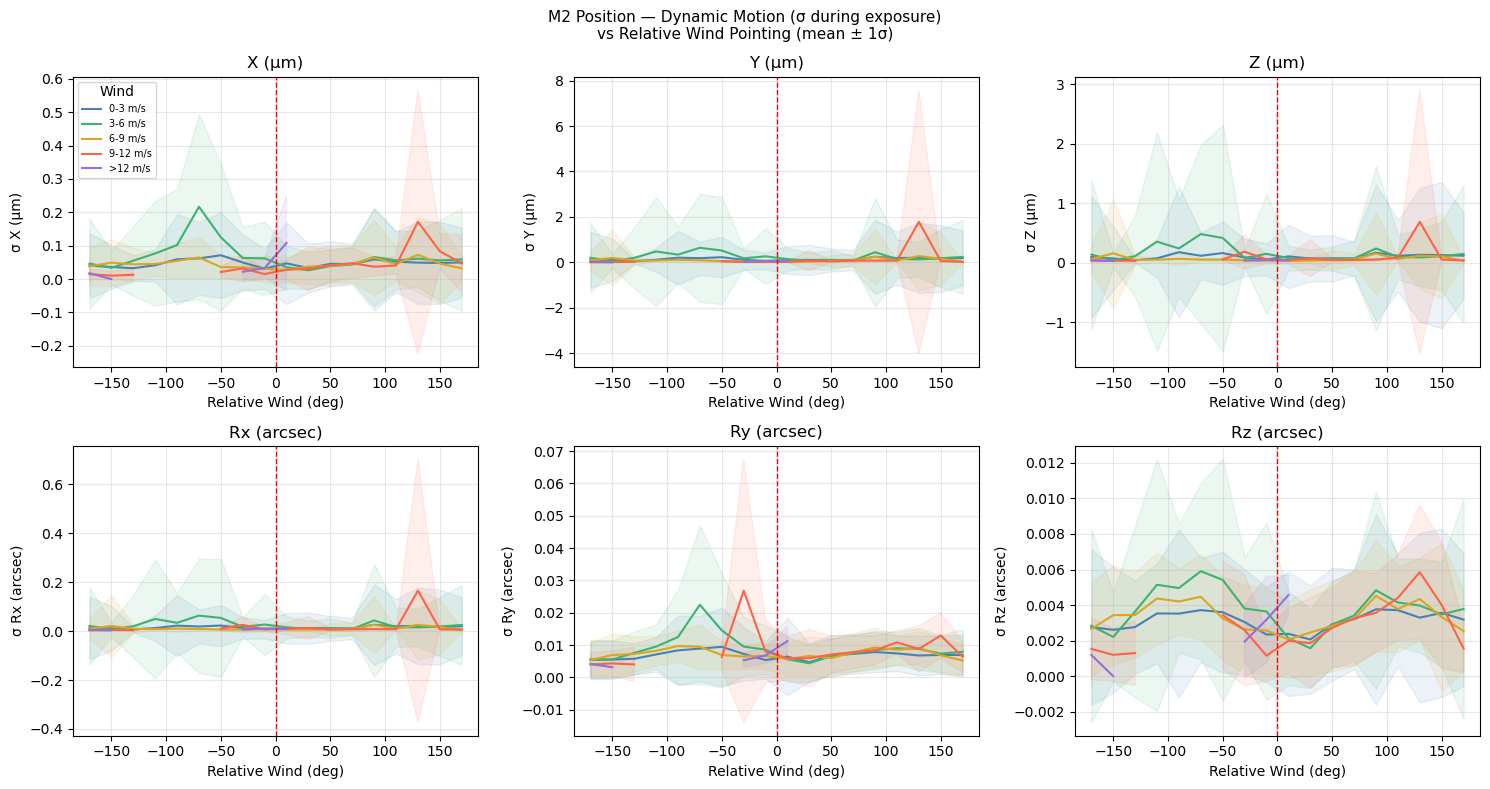

In [53]:
bin_edges_rw   = np.arange(-180, 181, 20)
bin_centers_rw = 0.5 * (bin_edges_rw[:-1] + bin_edges_rw[1:])

# Pull mirror columns from df_joined into df_sci_wind
mirror_new_cols = [c for c in df_joined.columns
                   if any(c.startswith(k) for k in mirror_topics)]
df_sci_wind = df_sci_wind.drop(
    columns=[c for c in mirror_new_cols if c in df_sci_wind.columns],
    errors="ignore",
).join(df_joined[mirror_new_cols], how="left")

# Topic display config: key → (title, [(col_suffix, panel_label), ...])
topic_display = {
    "m1m3_ims": (
        "M1M3 IMS — Dynamic Motion (σ during exposure)",
        [("xPosition", "X (µm)"), ("yPosition", "Y (µm)"), ("zPosition", "Z (µm)"),
         ("xRotation", "Rx (arcsec)"), ("yRotation", "Ry (arcsec)"), ("zRotation", "Rz (arcsec)")],
    ),
    "m1m3_hp": (
        "M1M3 Hardpoint Forces — Dynamic Variation (σ during exposure)",
        [(f"measuredForce{i}", f"HP{i} (N)") for i in range(6)],
    ),
    "m2_pos": (
        "M2 Position — Dynamic Motion (σ during exposure)",
        [("x", "X (µm)"), ("y", "Y (µm)"), ("z", "Z (µm)"),
         ("xRot", "Rx (arcsec)"), ("yRot", "Ry (arcsec)"), ("zRot", "Rz (arcsec)")],
    ),
}

for key, (title, panels) in topic_display.items():
    available = [f"{key}_{suf}_std" for suf, _ in panels
                 if f"{key}_{suf}_std" in df_sci_wind.columns
                 and df_sci_wind[f"{key}_{suf}_std"].notna().any()]
    if not available:
        print(f"[{key}] No data available — skipping")
        continue

    ncols = 3
    nrows = (len(panels) + ncols - 1) // ncols

    for fig_title, x_col, x_label, extra_fn in [
        (f"{title}\nvs Wind Speed",
         "wind_speed_best", "Wind Speed (m/s)", None),
        (f"{title}\nvs Relative Wind Pointing (mean ± 1σ)",
         "relative_wind",  "Relative Wind (deg)", lambda ax: (
             ax.axvline(0, color="red", lw=1, ls="--"),
             ax.set_xlim(-185, 185))),
    ]:
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                                 squeeze=False)
        for idx, (suf, lbl) in enumerate(panels):
            ax  = axes[idx // ncols][idx % ncols]
            col = f"{key}_{suf}_std"
            if col not in df_sci_wind.columns or df_sci_wind[col].isna().all():
                ax.set_visible(False)
                continue
            sub = df_sci_wind.dropna(subset=[col, x_col])

            if x_col == "wind_speed_best":
                for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
                    s = sub[sub["speed_bin"] == blab]
                    ax.scatter(s[x_col], s[col], s=5, alpha=0.35,
                               color=bcol, label=blab)
            else:
                for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
                    s = sub[sub["speed_bin"] == blab]
                    if s.empty:
                        continue
                    bi    = np.digitize(s[x_col], bin_edges_rw) - 1
                    means = np.array([s.loc[bi == b, col].mean()
                                      if (bi == b).any() else np.nan
                                      for b in range(len(bin_centers_rw))])
                    stds  = np.array([s.loc[bi == b, col].std()
                                      if (bi == b).any() else np.nan
                                      for b in range(len(bin_centers_rw))])
                    ax.plot(bin_centers_rw, means, lw=1.5, color=bcol, label=blab)
                    ax.fill_between(bin_centers_rw, means - stds, means + stds,
                                    alpha=0.1, color=bcol)

            ax.set_xlabel(x_label)
            ax.set_ylabel(f"σ {lbl}")
            ax.set_title(lbl)
            ax.grid(True, alpha=0.3)
            if extra_fn:
                extra_fn(ax)
            if idx == 0:
                ax.legend(fontsize=7, title="Wind")

        for idx in range(len(panels), nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)
        fig.suptitle(fig_title, fontsize=11)
        plt.tight_layout()
        plt.show()

## 9. Inside Turbulence vs Relative Wind Pointing

Inside wind speed from TMA sensors, joined from EFD — same analysis as
`ESS_Wind_vs_DomePointing.ipynb` but now anchored to actual science exposures
rather than continuous time series.

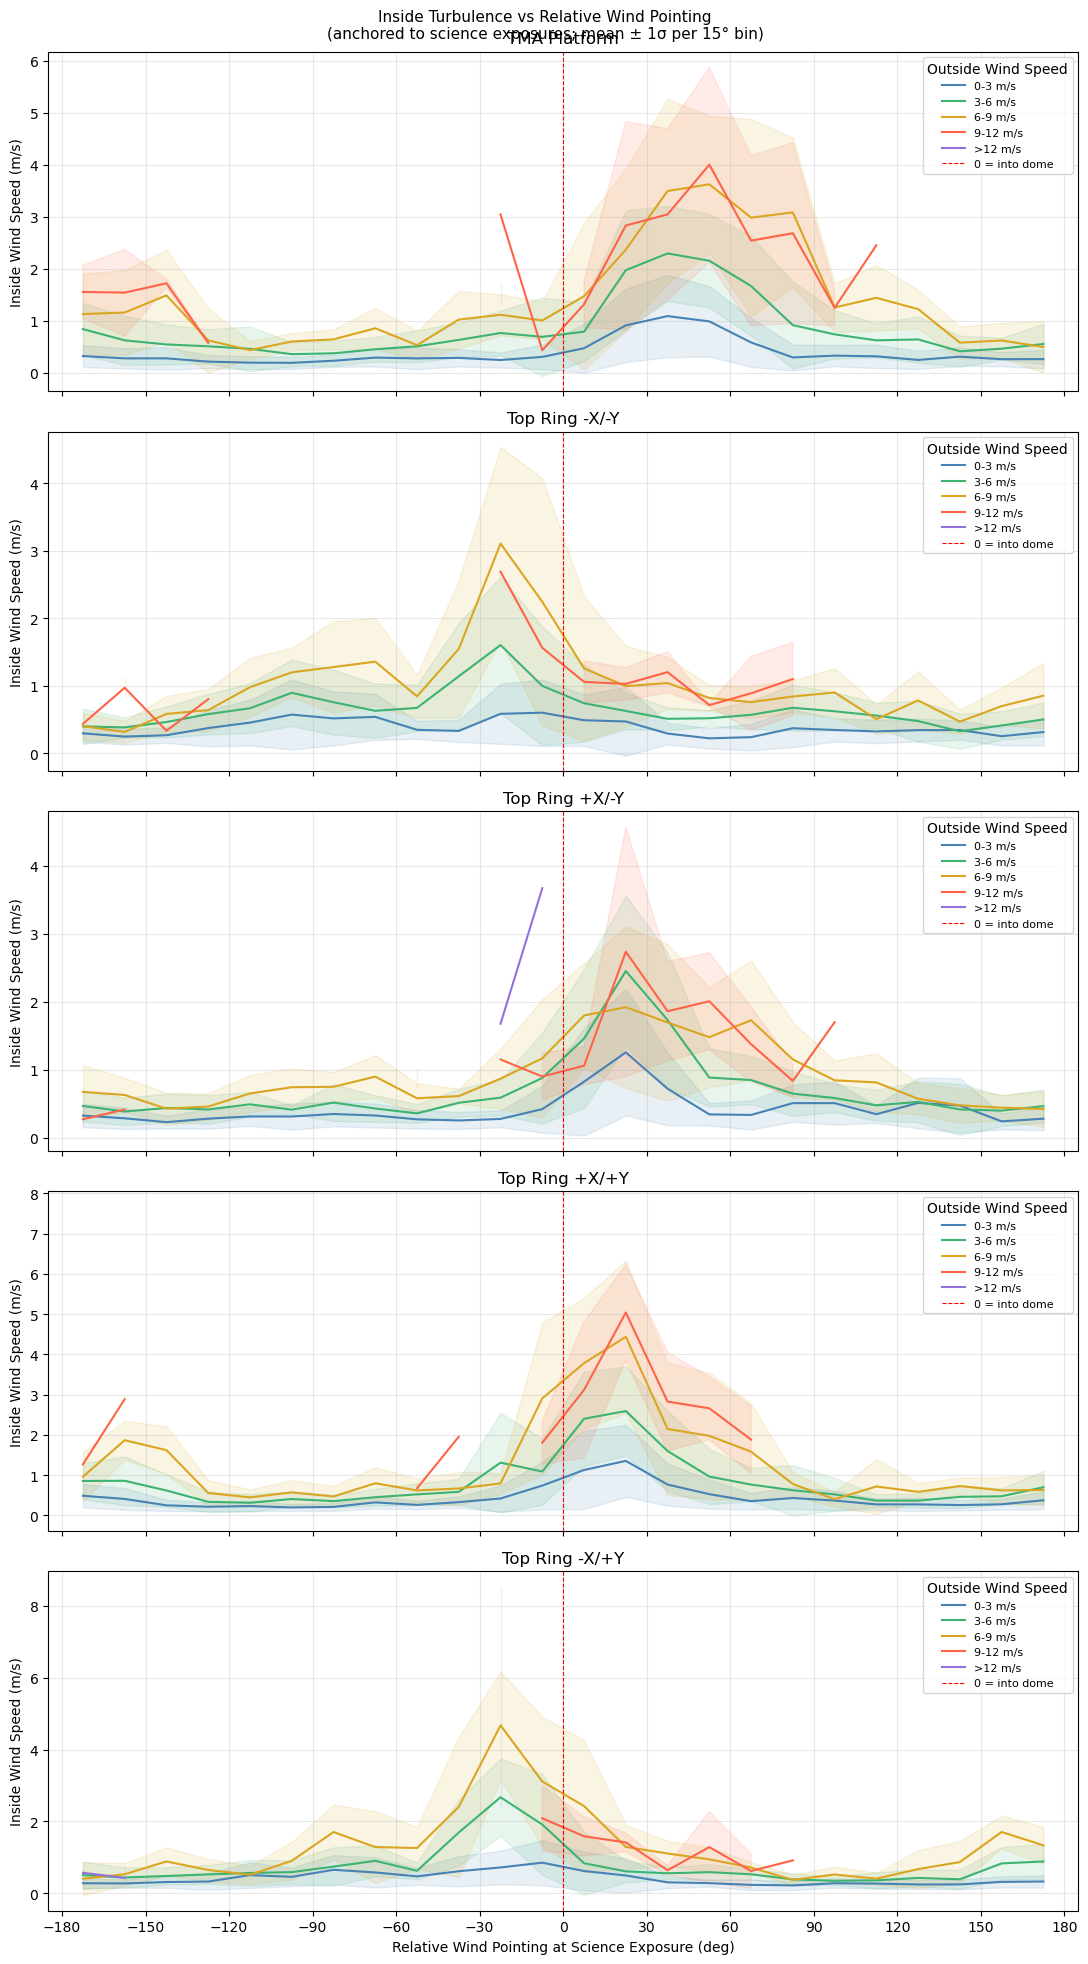

In [54]:
bin_edges_t   = np.arange(-180, 181, 15)
bin_centers_t = 0.5 * (bin_edges_t[:-1] + bin_edges_t[1:])

turb_cols = [(f"turb_speed_{idx}", label) for idx, label in ess_sensors.items()]
turb_cols = [(col, lbl) for col, lbl in turb_cols if col in df_sci_wind.columns]

if turb_cols:
    n_rows = len(turb_cols)
    fig, axes = plt.subplots(n_rows, 1, figsize=(11, 4 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    for ax, (tcol, tlabel) in zip(axes, turb_cols):
        for blab, bcol in zip(wind_speed_labels, wind_speed_colors):
            sub = df_sci_wind[df_sci_wind["speed_bin"] == blab].dropna(
                subset=["relative_wind", tcol]
            )
            if sub.empty:
                continue
            bi    = np.digitize(sub["relative_wind"], bin_edges_t) - 1
            means = [sub.loc[bi == b, tcol].mean() if (bi == b).any() else np.nan
                     for b in range(len(bin_centers_t))]
            stds  = [sub.loc[bi == b, tcol].std()  if (bi == b).any() else np.nan
                     for b in range(len(bin_centers_t))]
            means, stds = np.array(means), np.array(stds)
            ax.plot(bin_centers_t, means, lw=1.5, color=bcol, label=blab)
            ax.fill_between(bin_centers_t, means - stds, means + stds, alpha=0.12, color=bcol)

        ax.axvline(0, color="red", lw=0.8, ls="--", label="0 = into dome")
        ax.set_ylabel("Inside Wind Speed (m/s)")
        ax.set_title(tlabel)
        ax.set_xlim(-185, 185)
        ax.set_xticks(range(-180, 181, 30))
        ax.legend(fontsize=8, title="Outside Wind Speed")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Relative Wind Pointing at Science Exposure (deg)")
    fig.suptitle(
        "Inside Turbulence vs Relative Wind Pointing\n"
        "(anchored to science exposures; mean ± 1σ per 15° bin)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No turbulence columns found in joined table")

## 10. Summary & Next Steps

### What this notebook established

1. **Database**: `usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu / exposurelog`
   has current LSSTCam data (Apr 2025–present) plus `cdb_lsstcomcam`, `cdb_latiss`,
   and star tracker schemas.

2. **ConsDB column names** (lsstcam schema, different from LATISS):
   `img_type='science'`, `obs_start`, `s_ra/s_dec`, `exp_time`, `air_temp`,
   `sky_rotation`.  No `dome_azimuth` — fetch from `lsst.sal.MTDome.azimuth`.

3. **`visit1_quicklook`** provides per-visit PSF σ, effective time, seeing
   (zenith-corrected 500 nm), Zernikes z4–z28, guider FWHM.
   **`exposure_quicklook`** provides mount jitter and image degradation.

4. **EFD join** via `merge_asof` adds dome azimuth, shutter state, inside
   turbulence — anchored to individual science exposures.

### Schema column reference

| Notebook variable | ConsDB column | Notes |
|---|---|---|
| `df_exp["wind_speed"]` | `exposure.wind_speed` | Pre-computed EFD median |
| `df_exp["dome_azimuth_efd"]` | *(from EFD)* | Interp from MTDome.azimuth |
| `df_exp["psf_sigma_median"]` | `visit1_quicklook.psf_sigma_median` | |
| `df_exp["mount_jitter_rms"]` | `exposure_quicklook.mount_jitter_rms` | |
| `df_exp["turb_speed_110"]` | *(from EFD)* | ESS:110 TMA Platform |

### Potential follow-on analyses

| Question | Required columns |
|---|---|
| Does `relative_wind` predict PSF size? | `psf_sigma_median` + `dome_azimuth_efd` |
| Does wind speed predict mount jitter? | `mount_jitter_rms` + `wind_speed` |
| Is there a preferred dome pointing angle? | `relative_wind` + `eff_time_median` |
| Correlate Zernikes with turbulence? | `z4`–`z11` + `turb_speed_*` |
| Compare summit vs USDF seeing? | `dimm_seeing` + `seeing_zenith_500nm_median` |